In [1]:
import pandas as pd
from sqlalchemy import create_engine
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot
import random
import json
from scipy.interpolate import CubicSpline

In [2]:
db_username_0 = 'simulationuser'
db_password_0 = 'simulations2024'
db_host_0 = 'localhost'
db_port_0 = '5432'
db_name_0 = 'simulations_data'
table_name_0 = 'composite_data'

In [3]:
connection_string = f"postgresql://{db_username_0}:{db_password_0}@{db_host_0}:{db_port_0}/{db_name_0}"
engine = create_engine(connection_string)
query = f"SELECT * FROM {table_name_0}"
df = pd.read_sql(query, engine)

In [4]:
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list
0,1500,0.123943,318.864022,"[-0.011744609035812982, -0.011215305626181015,...","[-5.517162102724528, -3.1920707854231463, -0.9...","[-0.0016475367466768115, -0.002355776502265530...","[10.73076649947905, 10.77581128940965, 10.5402...","[0.4615413218450946, 0.4686702377764153, 0.478...","[0.6551578220909112, 0.8945764375320215, 1.175...","[0.00013793584140409996, 0.0001257830802886475...","[30.43907766773974, 10.189315899151941, 0.8663...","[2.7143773316504123e-06, 5.549682928626416e-06...","[115.14934966634185, 116.11810894496844, 111.0...","[0.06479691188370344, 0.035800049438924265, 0....","[-0.1260286571909809, -0.12085401698078094, -0...","[0.009089727301611367, 0.007519805349868124, 0...","[-59.203378264111755, -34.39715240615747, -9.8...","[-0.01767933212790023, -0.025385403028438877, ...","[[1.0369206541904592], [-1.6813054180526377], ..."
1,1501,0.123943,318.864022,"[-0.008147157474100065, -0.008292099833020762,...","[-0.832904729882089, 0.14071461474575664, 1.27...","[0.0006807256129005129, 0.0007313699095774325,...","[-0.7190970906032216, -0.6095182673572732, -0....","[0.23703131704960073, 0.23479400902756253, 0.2...","[-0.18778048603775238, -0.2053401462453807, -0...","[6.637617490778455e-05, 6.875891964078295e-05,...","[0.6937302890599556, 0.019800602803046713, 1.6...","[4.6338736005877887e-07, 5.349019446353018e-07...","[0.5171006257140178, 0.3715125182422124, 0.293...","[0.006785805995272157, -0.0011668196334368695,...","[0.005858597236311648, 0.005054186322976349, 0...","[-0.0005669795827367211, 0.0001029144350628272...","[0.5989393680078723, -0.0857681281716798, -0.6...","[-0.0004895078077358536, -0.000445783320082882...","[[1.418213787060706], [0.8827834628841255], [0..."
2,1502,0.123943,318.864022,"[-0.003781434990007615, -0.001308768972368787,...","[7.429632504232679, 7.616174400779771, 7.45893...","[0.0017201097552821953, 0.0016973192181066884,...","[0.26192796713213556, -0.016191321040263613, -...","[0.3398928494975913, 0.33847860008307173, 0.33...","[-0.22023434840890527, -0.0752140155360062, 0....","[1.4299250583653892e-05, 1.7128762230352505e-0...","[55.199439147950756, 58.00611250309311, 55.635...","[2.958777570216974e-06, 2.8808925281543e-06, 2...","[0.06860625996597308, 0.0002621588770288832, 0...","[-0.028094672314403355, -0.009967812743890003,...","[-0.000990463579775022, 2.1190698599158928e-05...","[0.012779783348692317, 0.012927079178895698, 0...","[1.9460285383725033, -0.12331592482166262, -2....","[0.00045054485144522063, -2.7481840368174608e-...","[[-0.6679438799496836], [-0.8041216677662598],..."
3,1503,0.123943,318.864022,"[-0.008102021680746106, -0.007577287179778589,...","[-13.405475487140006, -12.142974722866745, -10...","[-0.007065355563569785, -0.007211423776971252,...","[3.432058579711073, 2.9279736455346024, 2.4210...","[0.15021463519080008, 0.17082991418834997, 0.1...","[1.9382048681079675, 1.850150346137473, 2.4148...","[6.564275531527996e-05, 5.7415281004836965e-05...","[179.70677303631157, 147.4518351201807, 119.05...","[4.991924923966652e-05, 5.2004632891066315e-05...","[11.779026094568387, 8.573029668945189, 5.8616...","[0.10861145303751879, 0.09201080669195365, 0.1...","[-0.0278066130224098, -0.022186097167038923, -...","[0.09471445081536302, 0.08756813663964214, 0.0...","[-46.00837716074533, -35.55430996694667, -26.4...","[-0.024248714180659044, -0.021114858765753426,...","[[0.20668630436664126], [1.0343110874926529], ..."
4,1504,0.123943,318.864022,"[-0.0007052290130828054, -0.003475921446700475...","[7.188510348955567, 7.255315274332748, 7.40112...","[0.01155266108186768, 0.011468163968599393, 0....","[-0.9665805895951766, 0.23618988496103174, 1.4...","[0.1388431307750241, 0.13278906064134477, 0.12...","[-0.2758572865676108, -1.349696442983

In [5]:
df = df.sample(frac=1).reset_index(drop=True)

In [6]:
df = df.head(5000)

In [7]:
def average_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np_arrays, axis=0)
    
    return average_array

In [8]:
#<U*k_e_psi_e>
temp_u_list = df['u_list'].apply(np.array)
temp_k_e_psi_e_list = df['k_e_psi_e_list'].apply(np.array)
UK_e_psi_e = np.array([i * j for i, j in zip(temp_u_list, temp_k_e_psi_e_list)])
average_UK_e_psi_e = average_arrays(*list(UK_e_psi_e))

In [9]:
#<U*k_e_psi_plus>
temp_u_list = df['u_list'].apply(np.array)
temp_k_e_psi_plus_list = df['k_e_psi_plus_list'].apply(np.array)
UK_e_psi_plus = np.array([i * j for i, j in zip(temp_u_list, temp_k_e_psi_plus_list)])
average_UK_e_psi_plus = average_arrays(*list(UK_e_psi_plus))

In [10]:
average_psi_e = average_arrays(*list(df['psi_e']))
average_b_e = average_arrays(*list(df['b_e']))
average_psi_plus = average_arrays(*list(df['psi_plus']))
average_b_plus = average_arrays(*list(df['b_plus']))
average_U = average_arrays(*list(df['u_list']))
average_R = average_arrays(*list(df['r_list']))

average_k_e_psi_e_list = average_arrays(*list(df['k_e_psi_e_list']))
average_k_e_b_e_list = average_arrays(*list(df['k_e_b_e_list']))
average_k_e_psi_plus_list = average_arrays(*list(df['k_e_psi_plus_list']))
average_k_e_b_plus_list = average_arrays(*list(df['k_e_b_plus_list']))
average_heat_flux_psi_e_b_e_list = average_arrays(*list(df['heat_flux_psi_e_b_e_list']))
average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df['heat_flux_psi_e_b_plus_list']))
average_b_e_psi_plus_list = average_arrays(*list(df['b_e_psi_plus_list']))
average_b_e_b_plus_list = average_arrays(*list(df['b_e_b_plus_list']))
average_psi_plus_b_plus_list = average_arrays(*list(df['psi_plus_b_plus_list']))
average_eta = average_arrays(*list(df['eta_list']))

In [11]:
epsilon = 0.12394270273516043
N_0_squared = 318.8640217310387
r_m = 0.1
k = 2 * np.pi * 6
m = 2 * np.pi * 3
m_u = 2 * np.pi * 7
dt = 0.001
total_time = 200
k_e_square = k**2 + m**2
k_plus_square = k**2 + (m + m_u)**2

In [12]:
k_e_square

1776.5287921960844

In [13]:
m_u**2

1934.4424626135142

In [14]:
p = k / k_e_square
q = -k / k_plus_square
r = k * N_0_squared
s = -k * (k_plus_square - m_u**2) / (2*k_e_square)
t = -k * (m_u**2 - k_e_square) / (2 * k_plus_square)
v = k / 2

In [15]:
bigW = np.array([[-1, p, 0, 0], [-r, -1, 0, 0], [0, 0, -1, q], [0, 0, r, -1]])
bigL = np.array([[0, 0, s, 0], [0, 0, 0, v], [t, 0, 0, 0], [0, -v, 0, 0]])
bigQ = np.array([[8/k_e_square, 0, 0, 0],[0, 0, 0, 0],[0, 0, 0, 0],[0, 0, 0, 0]])

In [16]:
def create_C_matrix(row):
    length = len(row['k_e_psi_e_list'])  
    matrices = []
    
    for i in range(length):
        ke_psi_e = row['k_e_psi_e_list'][i]
        ke_b_e = row['k_e_b_e_list'][i]
        ke_psi_plus = row['k_e_psi_plus_list'][i]
        ke_b_plus = row['k_e_b_plus_list'][i]
        
        heat_flux_psi_e_b_e = row['heat_flux_psi_e_b_e_list'][i]
        heat_flux_psi_e_b_plus = row['heat_flux_psi_e_b_plus_list'][i]
        b_e_psi_plus = row['b_e_psi_plus_list'][i]
        b_e_b_plus = row['b_e_b_plus_list'][i]
        
        psi_plus_b_plus = row['psi_plus_b_plus_list'][i]
        psi_e_psi_plus = row['r_list'][i] 

        C_matrix = np.array([
            [ke_psi_e, heat_flux_psi_e_b_e, psi_e_psi_plus/(0.25 * k * (k_plus_square - k_e_square)), heat_flux_psi_e_b_plus],
            [heat_flux_psi_e_b_e, ke_b_e, b_e_psi_plus, b_e_b_plus],
            [psi_e_psi_plus/(0.25 * k * (k_plus_square - k_e_square)), b_e_psi_plus, ke_psi_plus, psi_plus_b_plus],
            [heat_flux_psi_e_b_plus, b_e_b_plus, psi_plus_b_plus, ke_b_plus]
        ])
        
        matrices.append(C_matrix)

    return matrices 

In [17]:
df['C_Matrix'] = df.apply(create_C_matrix, axis = 1)
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list,C_Matrix
0,7503,0.123943,318.864022,"[-0.007142023942463336, -0.003941398022096664,...","[15.495246798680133, 15.895511912079499, 16.06...","[-0.0003541366739114194, -0.000304556809103315...","[-0.56406201044915, -0.7356369970011903, -0.90...","[0.04636904739956077, 0.046809898047108764, 0....","[0.08563759498843239, 0.04064347795272642, 0.0...","[5.100850599471953e-05, 1.55346183685875e-05, ...","[240.10267335200692, 252.66729894706125, 258.2...","[1.25412783809043e-07, 9.275484997119344e-08, ...","[0.31816595163193706, 0.5411617913569293, 0.81...","[-0.11066742363055186, -0.06265053921048411, -...","[0.004028544383661834, 0.0028994382049616213, ...","[-0.005487435162721152, -0.0048410863870066755...","[-8.740280061669273, -11.693326648798811, -14....","[0.0001997550442602503, 0.0002240432564650279,...","[[-0.9262099820503419], [-0.16306017225057526]...","[[[5.100850599471953e-05, -0.11066742363055186..."
1,9585,0.123943,318.864022,"[0.007566964723416071, 0.00517562589740512, 0....","[-1.2525133756144697, -1.8536196162548513, -1....","[0.004569752833074931, 0.0043093860249444026, ...","[2.5334660682558017, 3.173412728923162, 3.8081...","[0.44619761985669, 0.4561020170610119, 0.45983...","[1.1708106831698006, 0.7551800921294217, 0.179...","[5.725895512542325e-05, 2.6787103429890557e-05...","[1.5687897560931539, 3.435905681764782, 3.7531...","[2.0882640955396357e-05, 1.8570807911986118e-0...","[6.418450319003511, 10.07054834809155, 14.5019...","[-0.009477724528881475, -0.00959364168982675, ...","[0.01917064836646326, 0.016424397102969772, 0....","[-0.005723676546678469, -0.007987962469851463,...","[-3.173200137155793, -5.882300084804812, -7.37...","[0.011577313742911157, 0.013675460465402155, 0...","[[-2.111273432920507], [-1.0288801943239048], ...","[[[5.725895512542325e-05, -0.00947772452888147..."
2,5334,0.123943,318.864022,"[0.01040654004644137, 0.0146381942571391, 0.02...","[12.553942849752579, 10.953130055758992, 8.634...","[-0.0015150009455016887, -0.001551598755341012...","[0.8505782791992638, -0.5398581486093116, -1.7...","[0.5408746061732761, 0.5335809455534096, 0.523...","[-0.5338159181950535, -0.7690227455146745, -1....","[0.00010829607573818796, 0.0002142767311097401...","[157.6014810748539, 119.97105801837098, 74.558...","[2.2952278648710107e-06, 2.4074586975757772e-0...","[0.7234834090455807, 0.29144682061987354, 2.92...","[0.13064310900668652, 0.16033404547990895, 0.1...","[0.008851576925120327, -0.007902548450642572, ...","[-0.01901923528714932, -0.01699486296160388, -...","[10.67811110630845, -5.913136513379055, -14.75...","[-0.001288626897210084, 0.0008376432314429108,...","[[2.4289530453902644], [0.6304049197757797], [...","[[[0.00010829607573818796, 0.13064310900668652..."
3,5058,0.123943,318.864022,"[-0.006721992317026065, -0.003345750073971113,...","[11.620827529395475, 11.971686245033164, 12.03...","[-0.0031726587353493605, -0.003026001145523563...","[-0.9805425280002036, -2.153819544845854, -3.3...","[0.36293305761438005, 0.36722876933631315, 0.3...","[0.7220938202183266, 0.3427952858046637, 0.151...","[4.518518071015744e-05, 1.1194043557477706e-05...","[135.04363246795575, 143.32127154951624, 144.9...","[1.0065763450988603e-05, 9.156682932709919e-06...","[0.96146364921703, 4.638938631760002, 10.99294...","[-0.07811511337008137, -0.04005427013987866, -...","[0.006591199339734684, 0.007206141901488445, 0...","[-0.03686891997312488, -0.03622633629131904, -...","[-11.3947156031278, -25.7848518193147, -39.912...","[0.003110926816841391, 0.006517460409954595, 0...","[[0.28880632898420816], [0.4549921401554623], ...","[[[4.518518071015744e-05, -0.07811511337008137..."
4,2553,0.123943,318.864022,"[-0.0019355591443496866, -0.000543079020301307...","[14.850280094120981, 15.1963

In [18]:
C_Mat_Arr = df['C_Matrix']
C_Mat_Arr

0       [[[5.100850599471953e-05, -0.11066742363055186...
1       [[[5.725895512542325e-05, -0.00947772452888147...
2       [[[0.00010829607573818796, 0.13064310900668652...
3       [[[4.518518071015744e-05, -0.07811511337008137...
4       [[[3.746389201275691e-06, -0.02874359543232998...
                              ...                        
4995    [[[1.9833290331772232e-05, -0.0093549068831054...
4996    [[[1.6716419718808036e-05, -0.0081117580747889...
4997    [[[8.526895056783231e-07, 0.000554298391175839...
4998    [[[6.48138963335291e-05, 0.0971694504523766, 1...
4999    [[[0.00022831417164997364, -0.2313710951608791...
Name: C_Matrix, Length: 5000, dtype: object

In [19]:
#<WC>

C_Mat_Arr_Multiplied = C_Mat_Arr.apply(lambda matrix_list: [bigW @ matrix for matrix in matrix_list])
C_Mat_Arr_Multiplied[0][0]


array([[-2.39944417e-03,  5.20580440e+00, -1.18976243e-04,
        -1.89503048e-01],
       [-5.02500237e-01,  1.09021830e+03, -2.49164332e-02,
        -3.96864105e+01],
       [-3.08158446e-05,  6.68576753e-02, -1.52800114e-06,
        -2.43377051e-03],
       [ 2.63753240e-02, -5.72235767e+01,  1.30781829e-03,
         2.08306755e+00]])

In [20]:
average_WC = np.mean(C_Mat_Arr_Multiplied.tolist(), axis = 0)
average_WC


array([[[-2.66478831e-04,  1.24226554e+00,  5.16170413e-05,
         -8.36437511e-02],
        [-1.12944880e+00,  3.91881552e+01, -2.99678600e-02,
          1.72022776e+02],
        [ 9.55130930e-05,  2.97447939e-02,  6.23989493e-07,
         -1.34927142e-01],
        [ 4.13557643e-02,  3.51300264e+01,  1.17863645e-01,
         -3.70704484e+01]],

       [[-2.61136152e-04,  1.25090899e+00,  4.87803407e-05,
         -8.27681397e-02],
        [-1.10901961e+00,  3.67170720e+01, -2.99998691e-02,
          1.66609523e+02],
        [ 9.23737747e-05,  2.94408090e-02,  9.67813254e-07,
         -1.33783421e-01],
        [ 4.10756600e-02,  3.34686556e+01,  1.18103012e-01,
         -3.75302783e+01]],

       [[-2.49895620e-04,  1.25681278e+00,  4.64420596e-05,
         -8.37980334e-02],
        [-1.09653855e+00,  3.06595824e+01, -2.80476960e-02,
          1.65490218e+02],
        [ 9.18469240e-05,  2.98669443e-02,  1.11899842e-06,
         -1.32652661e-01],
        [ 3.91440971e-02,  3.21015967e+

In [21]:
average_WC_term = np.mean(average_WC, axis=0)
average_WC_term

array([[-3.19316812e-04,  1.69902371e+00,  7.96876592e-05,
         2.50818965e-02],
       [-1.56431451e+00,  2.71025601e+01,  1.95536436e-02,
        -7.65887143e+01],
       [-4.19425133e-05, -1.40308438e-02, -2.56278498e-07,
        -1.74344180e-01],
       [-2.94662994e-02,  4.25702340e+01,  1.29105587e-01,
        -4.27782228e+01]])

In [22]:
#<CW^T>
C_Mat_Arr_Multiplied = C_Mat_Arr.apply(lambda matrix_list: [matrix @ np.transpose(bigW) for matrix in matrix_list])
C_Mat_Arr_Multiplied[0][0]


array([[-2.39944417e-03, -5.02500237e-01, -3.08158446e-05,
         2.63753240e-02],
       [ 5.20580440e+00,  1.09021830e+03,  6.68576753e-02,
        -5.72235767e+01],
       [-1.18976243e-04, -2.49164332e-02, -1.52800114e-06,
         1.30781829e-03],
       [-1.89503048e-01, -3.96864105e+01, -2.43377051e-03,
         2.08306755e+00]])

In [23]:
average_WC_Transpose = np.mean(C_Mat_Arr_Multiplied.tolist(), axis = 0)
average_WC_Transpose


array([[[-2.66478831e-04, -1.12944880e+00,  9.55130930e-05,
          4.13557643e-02],
        [ 1.24226554e+00,  3.91881552e+01,  2.97447939e-02,
          3.51300264e+01],
        [ 5.16170413e-05, -2.99678600e-02,  6.23989493e-07,
          1.17863645e-01],
        [-8.36437511e-02,  1.72022776e+02, -1.34927142e-01,
         -3.70704484e+01]],

       [[-2.61136152e-04, -1.10901961e+00,  9.23737747e-05,
          4.10756600e-02],
        [ 1.25090899e+00,  3.67170720e+01,  2.94408090e-02,
          3.34686556e+01],
        [ 4.87803407e-05, -2.99998691e-02,  9.67813254e-07,
          1.18103012e-01],
        [-8.27681397e-02,  1.66609523e+02, -1.33783421e-01,
         -3.75302783e+01]],

       [[-2.49895620e-04, -1.09653855e+00,  9.18469240e-05,
          3.91440971e-02],
        [ 1.25681278e+00,  3.06595824e+01,  2.98669443e-02,
          3.21015967e+01],
        [ 4.64420596e-05, -2.80476960e-02,  1.11899842e-06,
          1.18383728e-01],
        [-8.37980334e-02,  1.65490218e+

In [24]:
average_WC_Transpose_term = np.mean(average_WC_Transpose, axis=0)
average_WC_Transpose_term

array([[-3.19316812e-04, -1.56431451e+00, -4.19425133e-05,
        -2.94662994e-02],
       [ 1.69902371e+00,  2.71025601e+01, -1.40308438e-02,
         4.25702340e+01],
       [ 7.96876592e-05,  1.95536436e-02, -2.56278498e-07,
         1.29105587e-01],
       [ 2.50818965e-02, -7.65887143e+01, -1.74344180e-01,
        -4.27782228e+01]])

In [25]:
#<ULC>
C_Mat_Arr_ULC_Multiplied = []

for idx, (matrix_list, u_list) in enumerate(zip(C_Mat_Arr, df['u_list'])):
    result = []
    for u, matrix in zip(u_list, matrix_list):
        uL = u * bigL  # Broadcast scalar u across the matrix L
        result_matrix = uL @ matrix  # Matrix multiplication
        result.append(result_matrix)
    C_Mat_Arr_ULC_Multiplied.append(result)

average_ULC = np.mean(C_Mat_Arr_ULC_Multiplied, axis = 0)
average_ULC


array([[[-2.97167777e-05,  1.43837838e-02, -1.30299184e-04,
          2.32220802e-02],
        [-1.15314031e-01, -2.77012706e+01, -1.20114208e-02,
          1.46213933e+02],
        [-1.68110730e-05,  1.53013006e-03, -4.52080796e-07,
          3.39158915e-03],
        [ 5.20244220e-02, -3.41225480e+02,  7.43988818e-03,
          2.77012706e+01]],

       [[-3.03067709e-05,  1.70531448e-02, -1.31067198e-04,
          2.41197563e-02],
        [-1.11775533e-01, -2.74104390e+01, -1.24757360e-02,
          1.44813622e+02],
        [-1.65592983e-05,  1.51070786e-03, -4.61056353e-07,
          3.28751568e-03],
        [ 5.13640673e-02, -3.45046265e+02,  8.82059214e-03,
          2.74104390e+01]],

       [[-2.81521137e-05,  1.94123733e-02, -1.31985886e-04,
          2.42830371e-02],
        [-1.10863175e-01, -2.81005849e+01, -1.25601916e-02,
          1.43342404e+02],
        [-1.64977580e-05,  1.39595397e-03, -4.28277592e-07,
          3.26068162e-03],
        [ 4.74624349e-02, -3.48002415e+

In [26]:
average_ULC_term = np.mean(average_ULC, axis=0)
average_ULC_term


array([[-1.55231138e-05,  7.64330478e-02, -2.90484197e-05,
         1.31143769e-02],
       [-1.98287720e-01, -3.97507670e+01, -6.78329841e-03,
         1.39442993e+01],
       [ 3.76457888e-08,  3.41746881e-04, -2.36152847e-07,
         5.83199177e-03],
       [ 1.16193940e-02,  2.08247237e+01,  3.95343351e-02,
         3.97507670e+01]])

In [27]:
#<UCL^T>
C_Mat_Arr_UCLT_Multiplied = []

L_transposed = bigL.T

for idx, (matrix_list, u_list) in enumerate(zip(C_Mat_Arr, df['u_list'])):
    result = []
    for u, matrix in zip(u_list, matrix_list):
        uC = u * matrix  # Multiply the scalar u with the matrix C
        result_matrix = uC @ L_transposed  # Multiply by the transposed matrix L
        result.append(result_matrix)
    C_Mat_Arr_UCLT_Multiplied.append(result)

average_UCLT = np.mean(C_Mat_Arr_UCLT_Multiplied, axis = 0)
average_UCLT
average_UCLT_term = np.mean(average_UCLT, axis=0)
average_UCLT_term


array([[-1.55231138e-05, -1.98287720e-01,  3.76457888e-08,
         1.16193940e-02],
       [ 7.64330478e-02, -3.97507670e+01,  3.41746881e-04,
         2.08247237e+01],
       [-2.90484197e-05, -6.78329841e-03, -2.36152847e-07,
         3.95343351e-02],
       [ 1.31143769e-02,  1.39442993e+01,  5.83199177e-03,
         3.97507670e+01]])

In [28]:
average_C_Matrix = np.mean(df['C_Matrix'].tolist(), axis = 0)
average_C_Matrix

array([[[ 9.46308389e-05, -8.09814583e-03,  2.28168973e-06,
         -1.39278221e-02],
        [-8.09814583e-03,  5.81587684e+01,  2.53991786e-03,
         -4.59795207e+00],
        [ 2.28168973e-06,  2.53991786e-03,  9.68279061e-06,
         -1.46787994e-03],
        [-1.39278221e-02, -4.59795207e+00, -1.46787994e-03,
          1.94252245e+01]],

       [[ 9.29171391e-05, -7.92713424e-03,  2.29541903e-06,
         -1.34826793e-02],
        [-7.92713424e-03,  5.85741400e+01,  2.40688847e-03,
         -4.53571299e+00],
        [ 2.29541903e-06,  2.40688847e-03,  9.69844429e-06,
         -1.51907631e-03],
        [-1.34826793e-02, -4.53571299e+00, -1.51907631e-03,
          1.92696284e+01]],

       [[ 9.18390193e-05, -7.44824185e-03,  2.14278545e-06,
         -1.33859079e-02],
        [-7.44824185e-03,  5.88749167e+01,  2.28950689e-03,
         -4.57968534e+00],
        [ 2.14278545e-06,  2.28950689e-03,  9.71975299e-06,
         -1.54364269e-03],
        [-1.33859079e-02, -4.57968534e+

In [29]:
average_C_matrix = np.array(average_C_Matrix)

# Time step (assuming it's constant)
delta_t = .01  # Replace with your actual time step

# Initialize an array to store the time derivatives
dC_dt = np.zeros_like(average_C_matrix)

# Forward difference for the first time point
dC_dt[0] = (average_C_matrix[1] - average_C_matrix[0]) / delta_t

# Central difference for the intermediate points
for i in range(1, len(average_C_matrix) - 1):
    dC_dt[i] = (average_C_matrix[i + 1] - average_C_matrix[i - 1]) / (2 * delta_t)

# Backward difference for the last time point
dC_dt[-1] = (average_C_matrix[-1] - average_C_matrix[-2]) / delta_t
dC_dt.shape

(1000, 4, 4)

In [30]:
average_C_matrix.shape

(1000, 4, 4)

In [31]:
s1 = average_WC + average_WC_Transpose + average_ULC + average_UCLT + epsilon*bigQ
s1

array([[[-3.42569348e-05,  1.18864977e-02,  1.98772183e-08,
          3.29585154e-02],
        [ 1.18864977e-02,  2.29737692e+01, -1.07043569e-02,
          1.21412549e+01],
        [ 1.98772183e-08, -1.07043569e-02,  3.43817394e-07,
         -6.23201998e-03],
        [ 3.29585154e-02,  1.21412549e+01, -6.23201998e-03,
         -1.87383558e+01]],

       [[-2.47515644e-05,  4.71669904e-02, -6.47238083e-06,
          3.37913438e-02],
        [ 4.71669904e-02,  1.86132660e+01, -1.15240883e-02,
         -1.54463964e-01],
        [-6.47238083e-06, -1.15240883e-02,  1.01351380e-06,
         -3.57230092e-03],
        [ 3.37913438e-02, -1.54463964e-01, -3.57230092e-03,
         -2.02396786e+01]],

       [[ 2.03881398e-06,  6.88234295e-02, -1.01946599e-05,
          2.70915357e-02],
        [ 6.88234295e-02,  5.11799499e+00, -9.34498937e-03,
         -7.06819673e+00],
        [-1.01946599e-05, -9.34498937e-03,  1.38144166e-06,
         -9.67368045e-04],
        [ 2.70915357e-02, -7.06819673e+

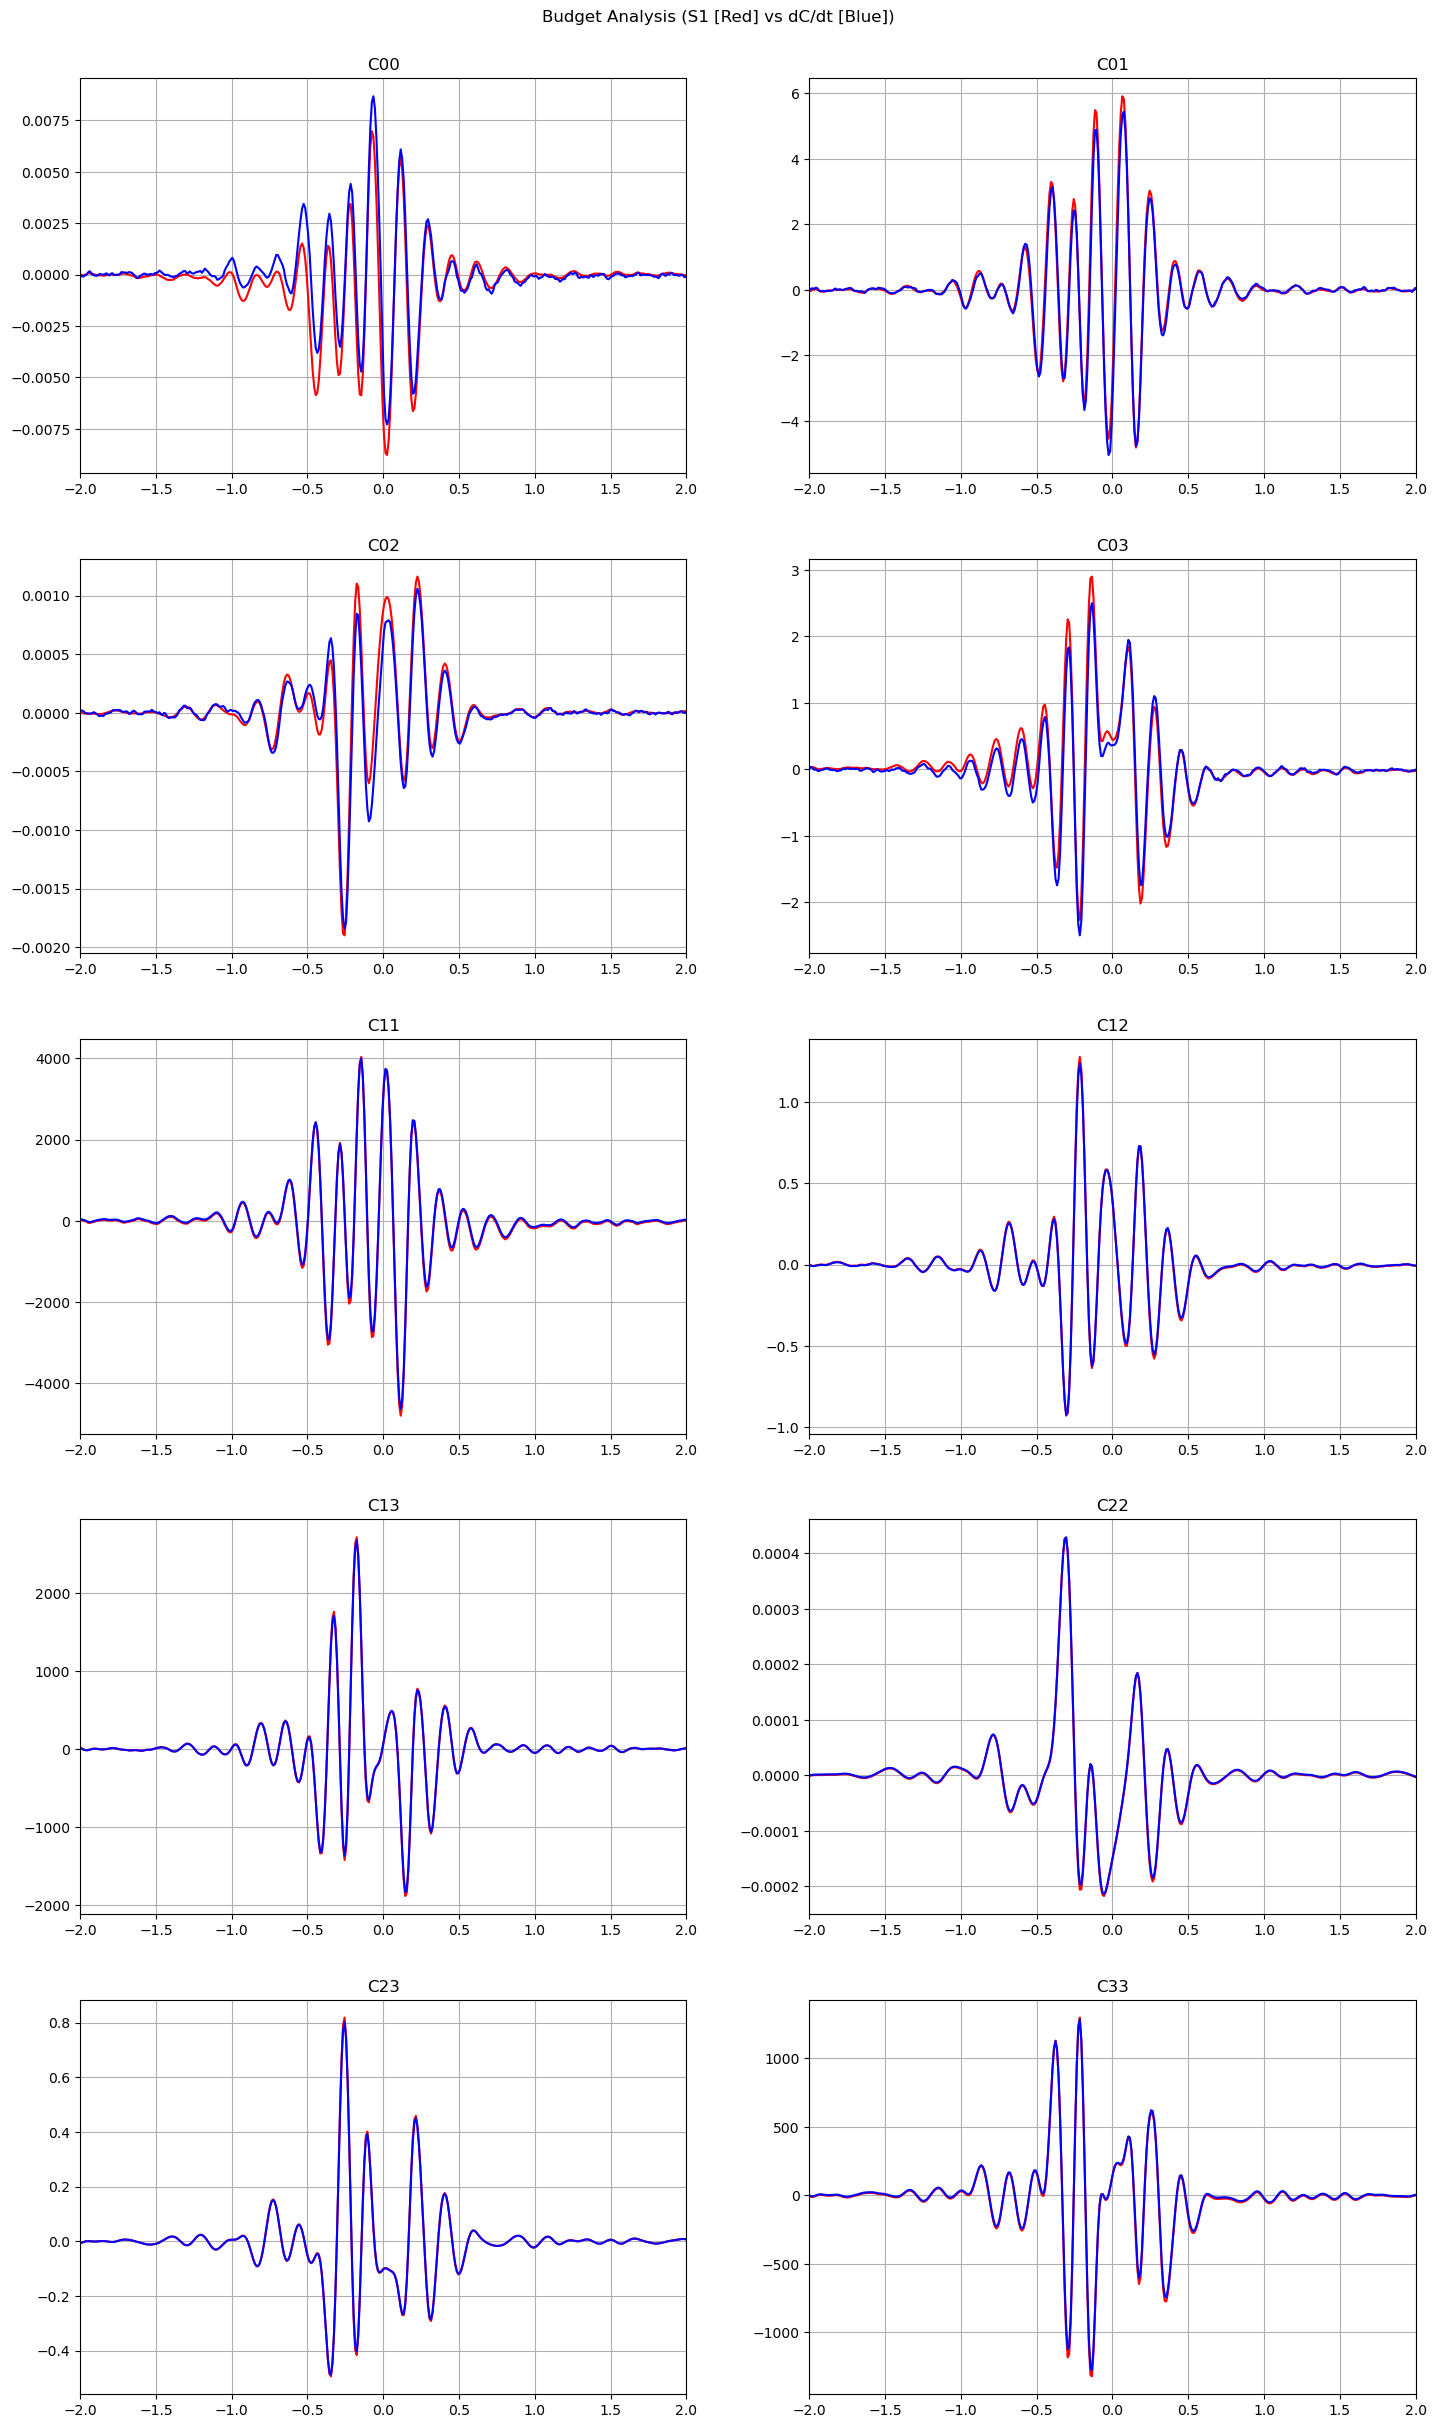

In [32]:
time_array = np.linspace(-5, 5,  int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s1[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s1[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s1[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s1[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s1[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s1[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s1[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s1[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s1[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s1[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S1 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

In [33]:
#W<C> term
W_C = np.array([bigW @ C for C in average_C_Matrix])
W_C

array([[[-2.66478831e-04,  1.24226554e+00,  5.16170413e-05,
         -8.36437511e-02],
        [-1.12944880e+00,  3.91881552e+01, -2.99678600e-02,
          1.72022776e+02],
        [ 9.55130930e-05,  2.97447939e-02,  6.23989493e-07,
         -1.34927142e-01],
        [ 4.13557643e-02,  3.51300264e+01,  1.17863645e-01,
         -3.70704484e+01]],

       [[-2.61136152e-04,  1.25090899e+00,  4.87803407e-05,
         -8.27681397e-02],
        [-1.10901961e+00,  3.67170720e+01, -2.99998691e-02,
          1.66609523e+02],
        [ 9.23737747e-05,  2.94408090e-02,  9.67813254e-07,
         -1.33783421e-01],
        [ 4.10756600e-02,  3.34686556e+01,  1.18103012e-01,
         -3.75302783e+01]],

       [[-2.49895620e-04,  1.25681278e+00,  4.64420596e-05,
         -8.37980334e-02],
        [-1.09653855e+00,  3.06595824e+01, -2.80476960e-02,
          1.65490218e+02],
        [ 9.18469240e-05,  2.98669443e-02,  1.11899842e-06,
         -1.32652661e-01],
        [ 3.91440971e-02,  3.21015967e+

In [34]:
#<C>W^T
CW_T = np.array([C @ bigW.T for C in average_C_Matrix])
CW_T

array([[[-2.66478831e-04, -1.12944880e+00,  9.55130930e-05,
          4.13557643e-02],
        [ 1.24226554e+00,  3.91881552e+01,  2.97447939e-02,
          3.51300264e+01],
        [ 5.16170413e-05, -2.99678600e-02,  6.23989493e-07,
          1.17863645e-01],
        [-8.36437511e-02,  1.72022776e+02, -1.34927142e-01,
         -3.70704484e+01]],

       [[-2.61136152e-04, -1.10901961e+00,  9.23737747e-05,
          4.10756600e-02],
        [ 1.25090899e+00,  3.67170720e+01,  2.94408090e-02,
          3.34686556e+01],
        [ 4.87803407e-05, -2.99998691e-02,  9.67813254e-07,
          1.18103012e-01],
        [-8.27681397e-02,  1.66609523e+02, -1.33783421e-01,
         -3.75302783e+01]],

       [[-2.49895620e-04, -1.09653855e+00,  9.18469240e-05,
          3.91440971e-02],
        [ 1.25681278e+00,  3.06595824e+01,  2.98669443e-02,
          3.21015967e+01],
        [ 4.64420596e-05, -2.80476960e-02,  1.11899842e-06,
          1.18383728e-01],
        [-8.37980334e-02,  1.65490218e+

In [35]:
U = np.mean(average_U)
U

0.021784976903318126

In [36]:
#<U>L<C>
result_ULC = np.array([U * (bigL @ C) for C in average_C_Matrix])
result_ULC

array([[[-1.81142999e-06, -2.01643691e-03, -7.68715266e-06,
          1.16534764e-03],
        [-5.71928106e-03, -1.88808989e+00, -6.02766023e-04,
          7.97671864e+00],
        [-1.14290991e-06,  9.78058660e-05, -2.75572513e-08,
          1.68214149e-04],
        [ 3.32539945e-03, -2.38821504e+01, -1.04298461e-03,
          1.88808989e+00]],

       [[-1.82232966e-06, -1.91082508e-03, -7.69958010e-06,
          1.20599236e-03],
        [-5.53648887e-03, -1.86253221e+00, -6.23789154e-04,
          7.91282510e+00],
        [-1.12221260e-06,  9.57404628e-05, -2.77230679e-08,
          1.62837908e-04],
        [ 3.25517574e-03, -2.40527174e+01, -9.88357800e-04,
          1.86253221e+00]],

       [[-1.70115410e-06, -1.81763602e-03, -7.71649704e-06,
          1.22549558e-03],
        [-5.49675095e-03, -1.88058889e+00, -6.33877022e-04,
          7.84813213e+00],
        [-1.10919154e-06,  8.99566098e-05, -2.58796262e-08,
          1.61669146e-04],
        [ 3.05852473e-03, -2.41762274e+

In [37]:
#<U><C>L^T 
result_UCLT = np.array([U * (C @ bigL.T) for C in average_C_Matrix])
result_UCLT

array([[[-1.81142999e-06, -5.71928106e-03, -1.14290991e-06,
          3.32539945e-03],
        [-2.01643691e-03, -1.88808989e+00,  9.78058660e-05,
         -2.38821504e+01],
        [-7.68715266e-06, -6.02766023e-04, -2.75572513e-08,
         -1.04298461e-03],
        [ 1.16534764e-03,  7.97671864e+00,  1.68214149e-04,
          1.88808989e+00]],

       [[-1.82232966e-06, -5.53648887e-03, -1.12221260e-06,
          3.25517574e-03],
        [-1.91082508e-03, -1.86253221e+00,  9.57404628e-05,
         -2.40527174e+01],
        [-7.69958010e-06, -6.23789154e-04, -2.77230679e-08,
         -9.88357800e-04],
        [ 1.20599236e-03,  7.91282510e+00,  1.62837908e-04,
          1.86253221e+00]],

       [[-1.70115410e-06, -5.49675095e-03, -1.10919154e-06,
          3.05852473e-03],
        [-1.81763602e-03, -1.88058889e+00,  8.99566098e-05,
         -2.41762274e+01],
        [-7.71649704e-06, -6.33877022e-04, -2.58796262e-08,
         -9.40156561e-04],
        [ 1.22549558e-03,  7.84813213e+

In [38]:
s2 = W_C + CW_T + result_ULC + result_UCLT + epsilon*bigQ
s2

array([[[ 2.15537606e-05,  1.05081027e-01,  1.38300072e-04,
         -3.77972397e-02],
        [ 1.05081027e-01,  7.46001305e+01, -7.28026315e-04,
          1.91247371e+02],
        [ 1.38300072e-04, -7.28026315e-04,  1.19286448e-06,
         -1.79382678e-02],
        [-3.77972397e-02,  1.91247371e+02, -1.79382678e-02,
         -7.03647171e+01]],

       [[ 3.22173181e-05,  1.34442065e-01,  1.32332323e-04,
         -3.72313117e-02],
        [ 1.34442065e-01,  6.97090796e+01, -1.08710883e-03,
          1.83938287e+02],
        [ 1.32332323e-04, -1.08710883e-03,  1.88018037e-06,
         -1.65059286e-02],
        [-3.72313117e-02,  1.83938287e+02, -1.65059286e-02,
         -7.13354922e+01]],

       [[ 5.49407332e-05,  1.52959844e-01,  1.29463295e-04,
         -4.03699160e-02],
        [ 1.52959844e-01,  5.75579870e+01,  1.27532786e-03,
          1.81263719e+02],
        [ 1.29463295e-04,  1.27532786e-03,  2.18623759e-06,
         -1.50474198e-02],
        [-4.03699160e-02,  1.81263719e+

In [39]:
diff = s1 - s2
diff

array([[[-5.58106954e-05, -9.31945292e-02, -1.38280195e-04,
          7.07557551e-02],
        [-9.31945292e-02, -5.16263614e+01, -9.97633058e-03,
         -1.79106116e+02],
        [-1.38280195e-04, -9.97633058e-03, -8.49047090e-07,
          1.17062478e-02],
        [ 7.07557551e-02, -1.79106116e+02,  1.17062478e-02,
          5.16263614e+01]],

       [[-5.69688826e-05, -8.72750742e-02, -1.38804703e-04,
          7.10226554e-02],
        [-8.72750742e-02, -5.10958136e+01, -1.04369794e-02,
         -1.84092751e+02],
        [-1.38804703e-04, -1.04369794e-02, -8.66666570e-07,
          1.29336277e-02],
        [ 7.10226554e-02, -1.84092751e+02,  1.29336277e-02,
          5.10958136e+01]],

       [[-5.29019193e-05, -8.41364148e-02, -1.39657955e-04,
          6.74614517e-02],
        [-8.41364148e-02, -5.24399921e+01, -1.06203172e-02,
         -1.88331916e+02],
        [-1.39657955e-04, -1.06203172e-02, -8.04795932e-07,
          1.40800518e-02],
        [ 6.74614517e-02, -1.88331916e+

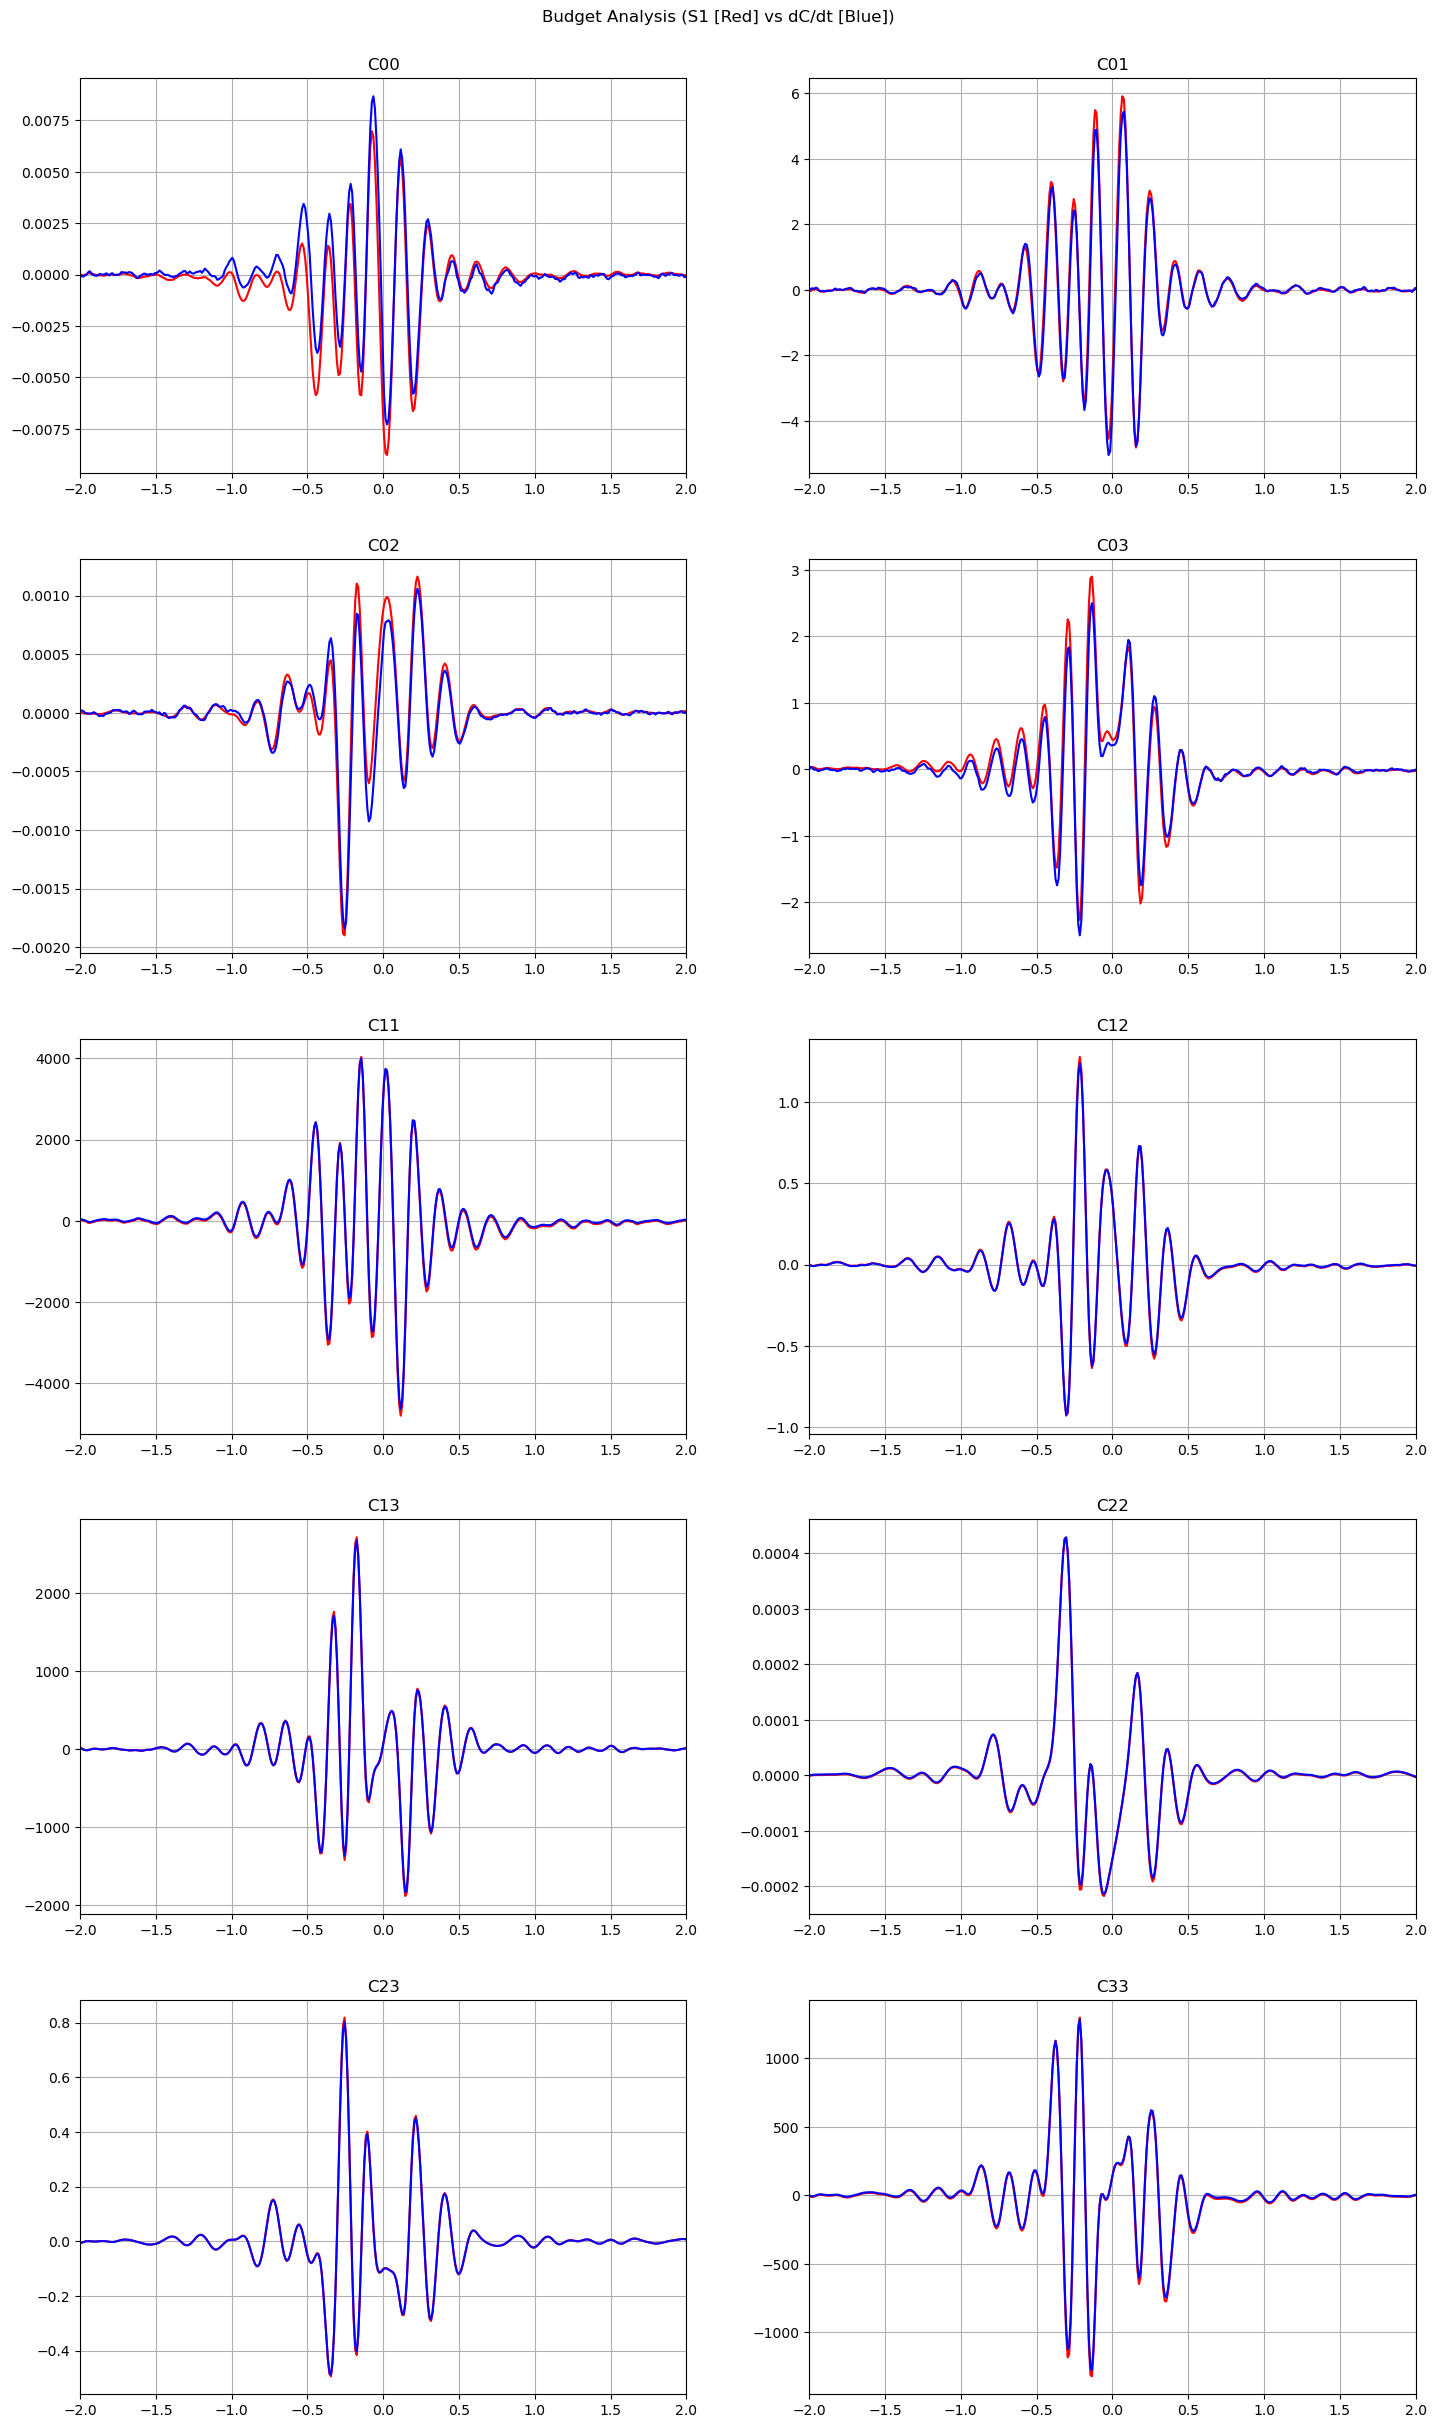

In [40]:
time_array = np.linspace(-5, 5, int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s1[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s1[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s1[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s1[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s1[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s1[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s1[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s1[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s1[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s1[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S1 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

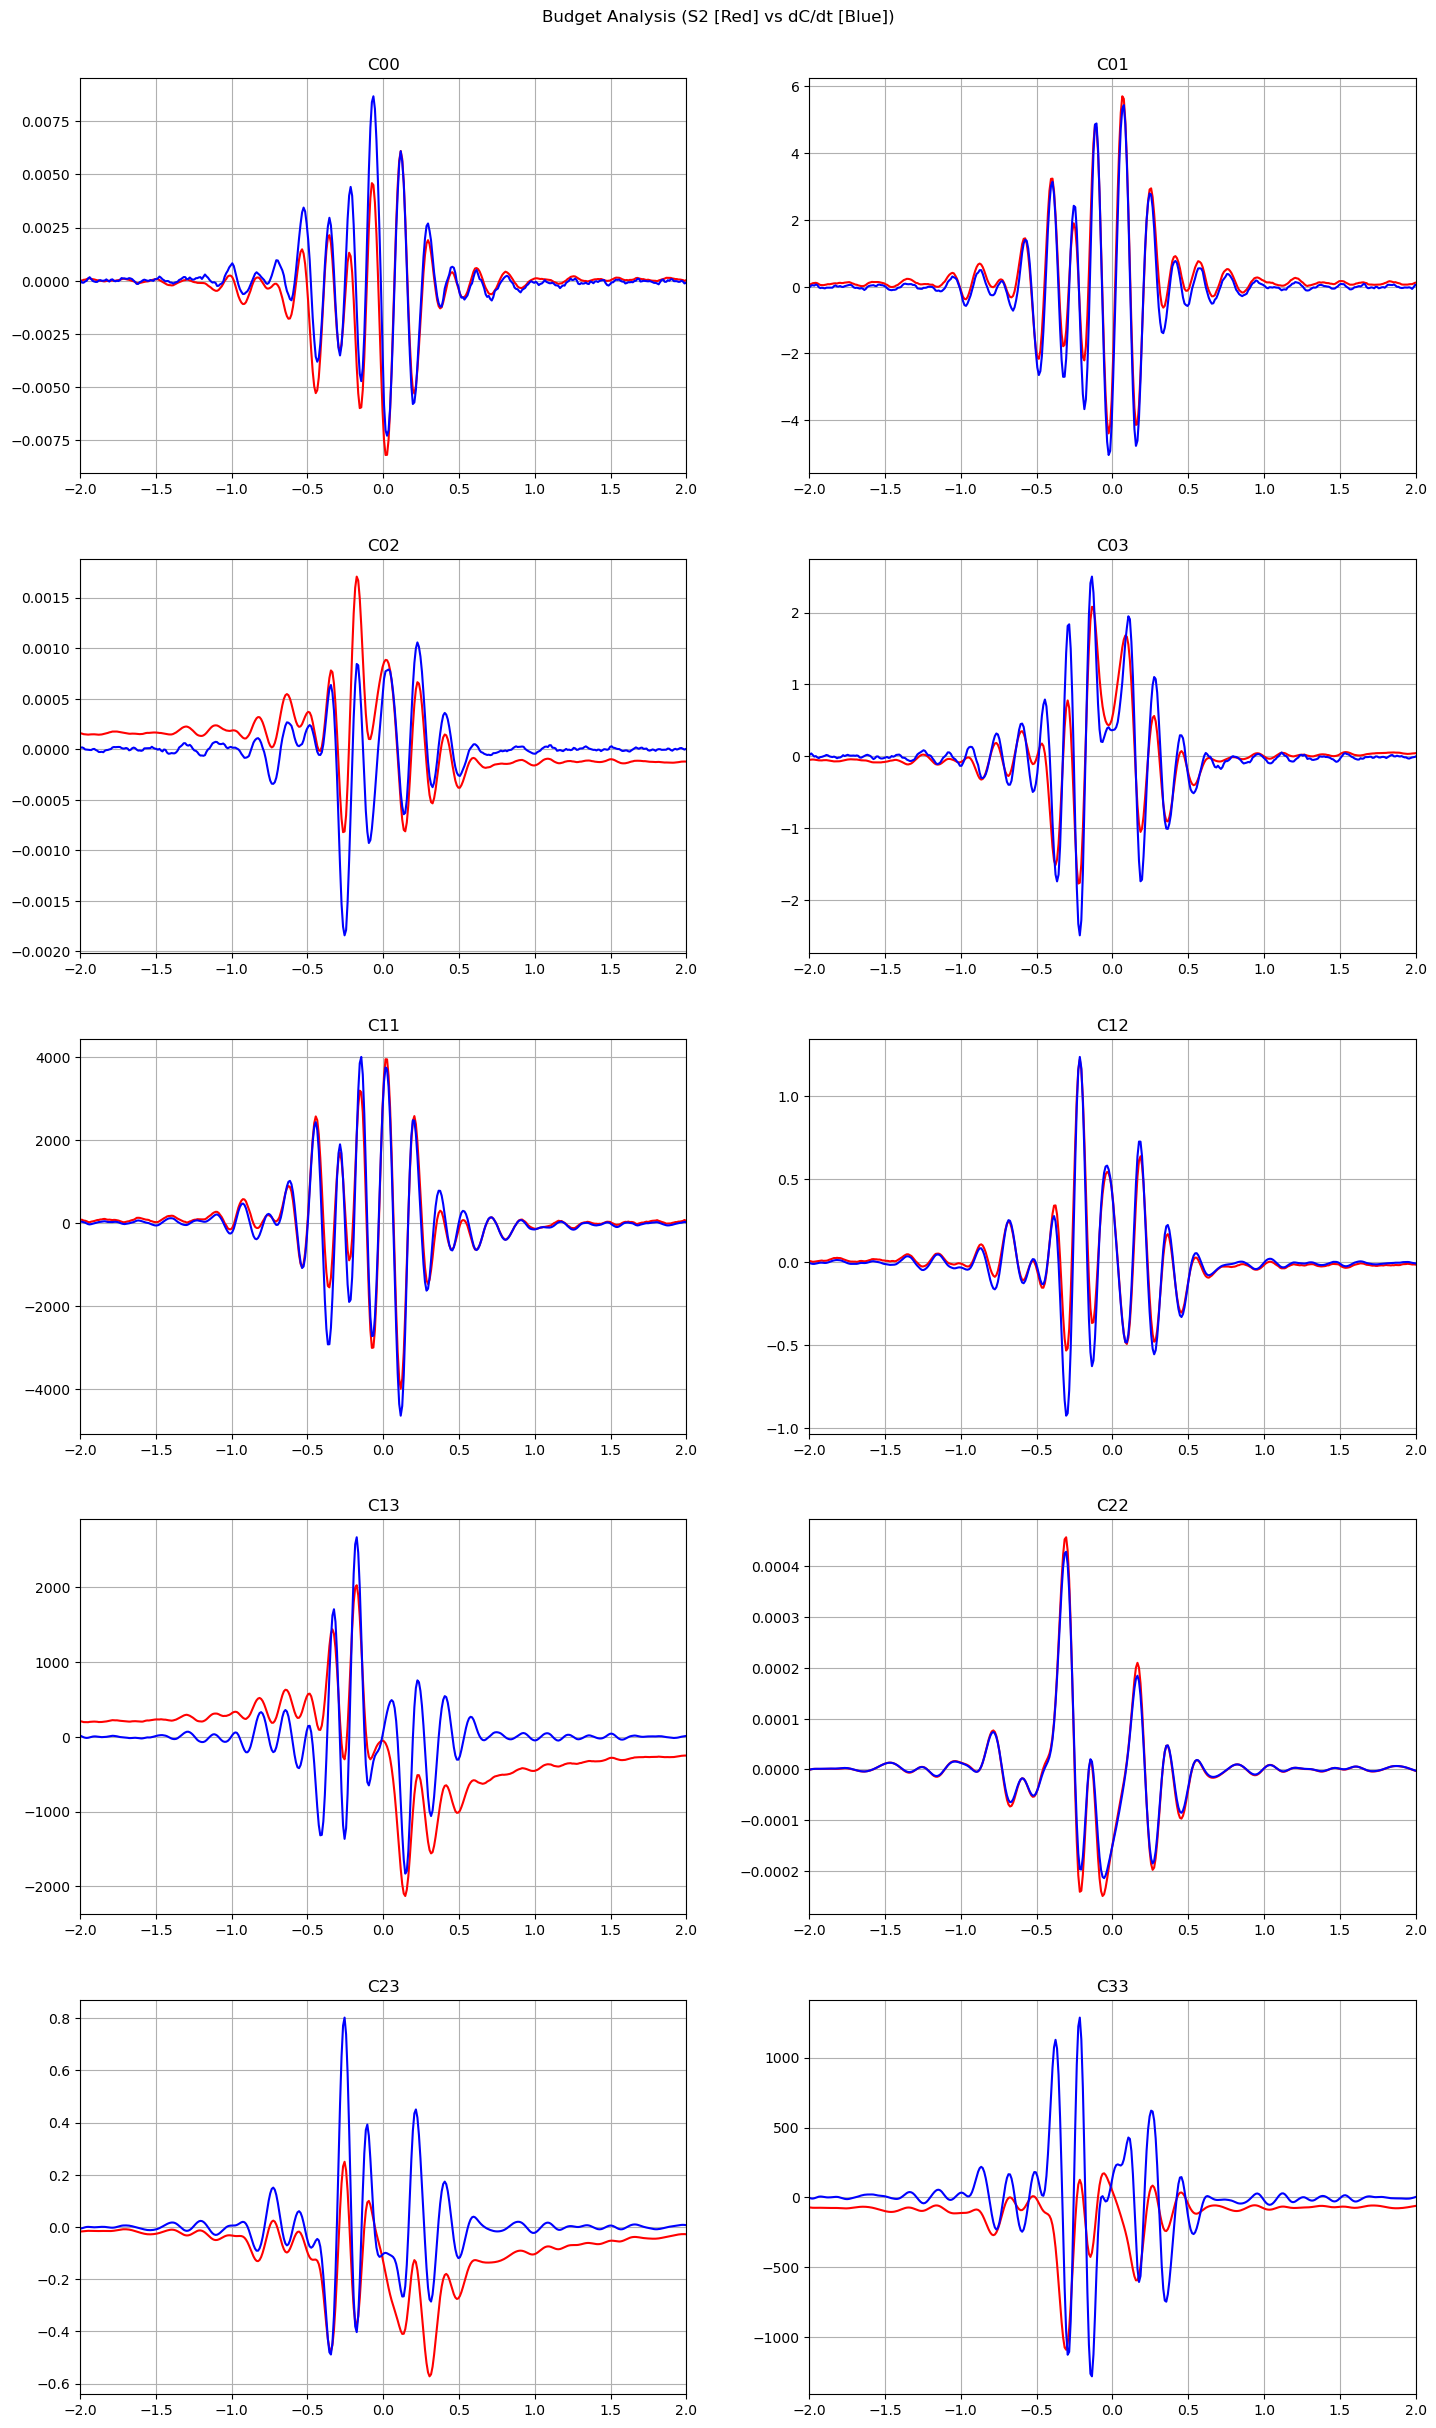

In [41]:
time_array = np.linspace(-5, 5, int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s2[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s2[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s2[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s2[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s2[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s2[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s2[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s2[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s2[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s2[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S2 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

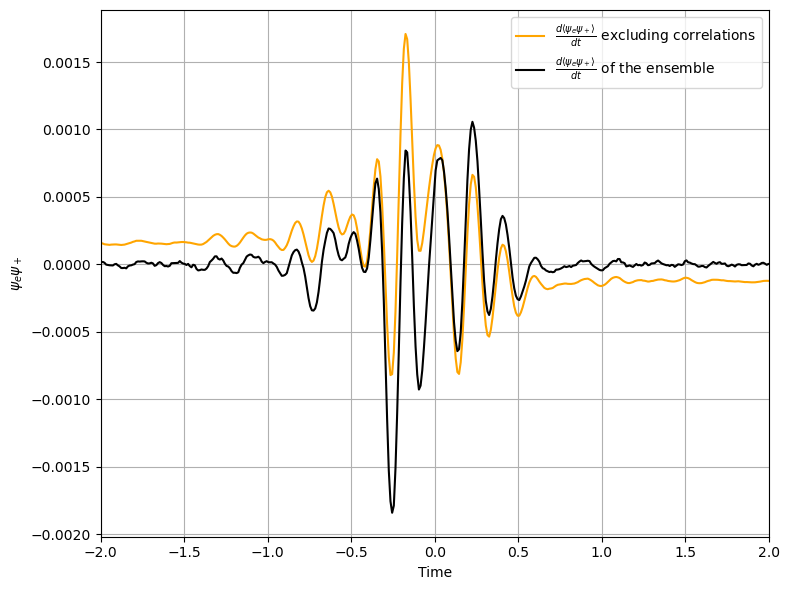

In [42]:
time_array = np.linspace(-5, 5, int(10/.01))
x_limit = (-2, 2)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

# Plotting with LaTeX legend labels
axs.plot(time_array, s2[:, 0, 2], 'orange', label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ excluding correlations')
axs.plot(time_array, dC_dt[:, 0, 2], 'black', label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ of the ensemble')

axs.set_xlabel('Time')
axs.set_ylabel(r'$\psi_e \psi_+$')
axs.set_xlim(x_limit)
axs.grid()

# Add the legend
axs.legend()

plt.tight_layout()
plt.show()

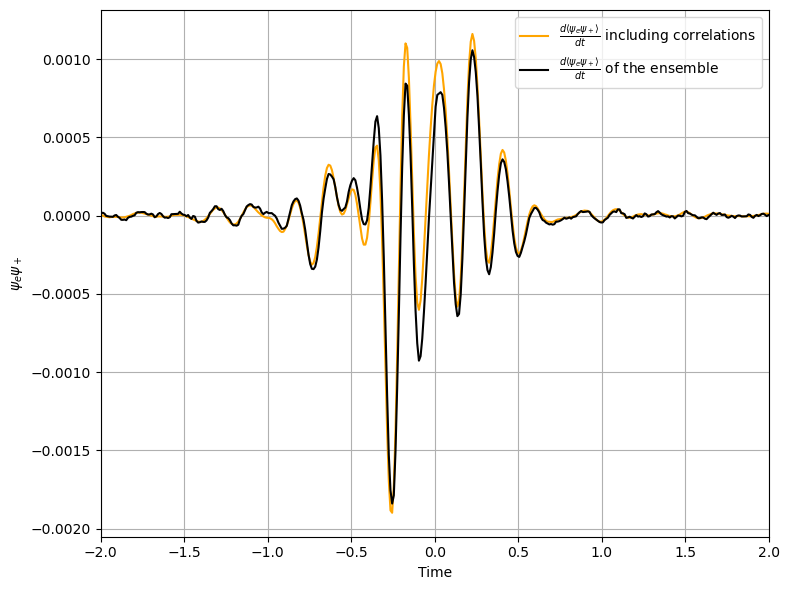

In [43]:
time_array = np.linspace(-5, 5, int(10/.01))
x_limit = (-2, 2)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

# Plotting with LaTeX legend labels
axs.plot(time_array, s1[:, 0, 2], 'orange', label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ including correlations')
axs.plot(time_array, dC_dt[:, 0, 2], 'black', label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ of the ensemble')

axs.set_xlabel('Time')
axs.set_ylabel(r'$\psi_e \psi_+$')
axs.set_xlim(x_limit)
axs.grid()

# Add the legend
axs.legend()

plt.tight_layout()
plt.show()

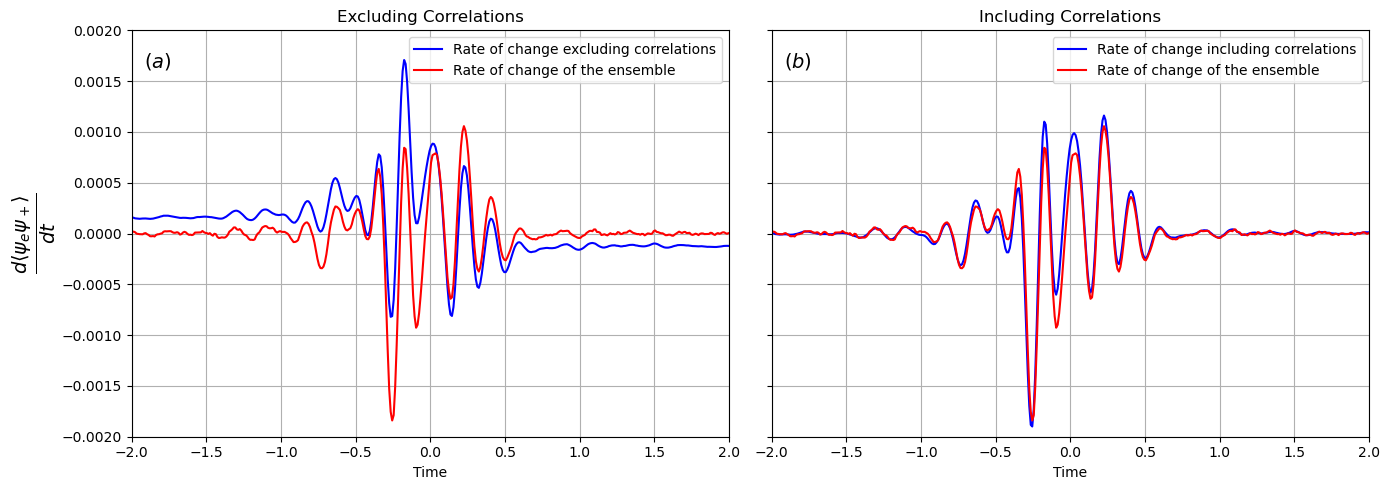

In [44]:
import numpy as np
import matplotlib.pyplot as plt

time_array = np.linspace(-5, 5, int(10 / 0.01))
x_limit = (-2, 2)
y_limit = (-0.002, 0.002)

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ---------- Left panel: Excluding Correlations ----------
ax = axs[0]
# ax.plot(time_array, s2[:, 0, 2], 'orange',
#         label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ excluding correlations')
# ax.plot(time_array, dC_dt[:, 0, 2], 'black',
#         label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ of the ensemble')
ax.plot(time_array, s2[:, 0, 2], 'blue',
        label=r'Rate of change excluding correlations')
ax.plot(time_array, dC_dt[:, 0, 2], 'red',
        label=r'Rate of change of the ensemble')

ax.set_xlabel('Time')
ax.set_ylabel(
    r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$',
#     rotation=360,
    va='center',
    labelpad=20,
    fontsize=20
)

ax.set_xlim(x_limit)
ax.set_ylim(y_limit)
ax.grid()
ax.set_title('Excluding Correlations')
ax.legend()

# panel label (a) inside the axes
ax.text(0.02, 0.95, r'$(a)$',
        transform=ax.transAxes,
        fontsize=14,
        va='top', ha='left')

# ---------- Right panel: Including Correlations ----------
ax = axs[1]
# ax.plot(time_array, s1[:, 0, 2], 'blue',
#         label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ including correlations')
# ax.plot(time_array, dC_dt[:, 0, 2], 'red',
#         label=r'$\frac{d\langle \psi_e \psi_+ \rangle}{dt}$ of the ensemble')
ax.plot(time_array, s1[:, 0, 2], 'blue',
        label=r'Rate of change including correlations')
ax.plot(time_array, dC_dt[:, 0, 2], 'red',
        label=r'Rate of change of the ensemble')

ax.set_xlabel('Time')
ax.set_xlim(x_limit)
ax.set_ylim(y_limit)
ax.grid()
ax.set_title('Including Correlations')
ax.legend()

# panel label (b) inside the axes
ax.text(0.02, 0.95, r'$(b)$',
        transform=ax.transAxes,
        fontsize=14,
        va='top', ha='left')

plt.tight_layout()
plt.show()


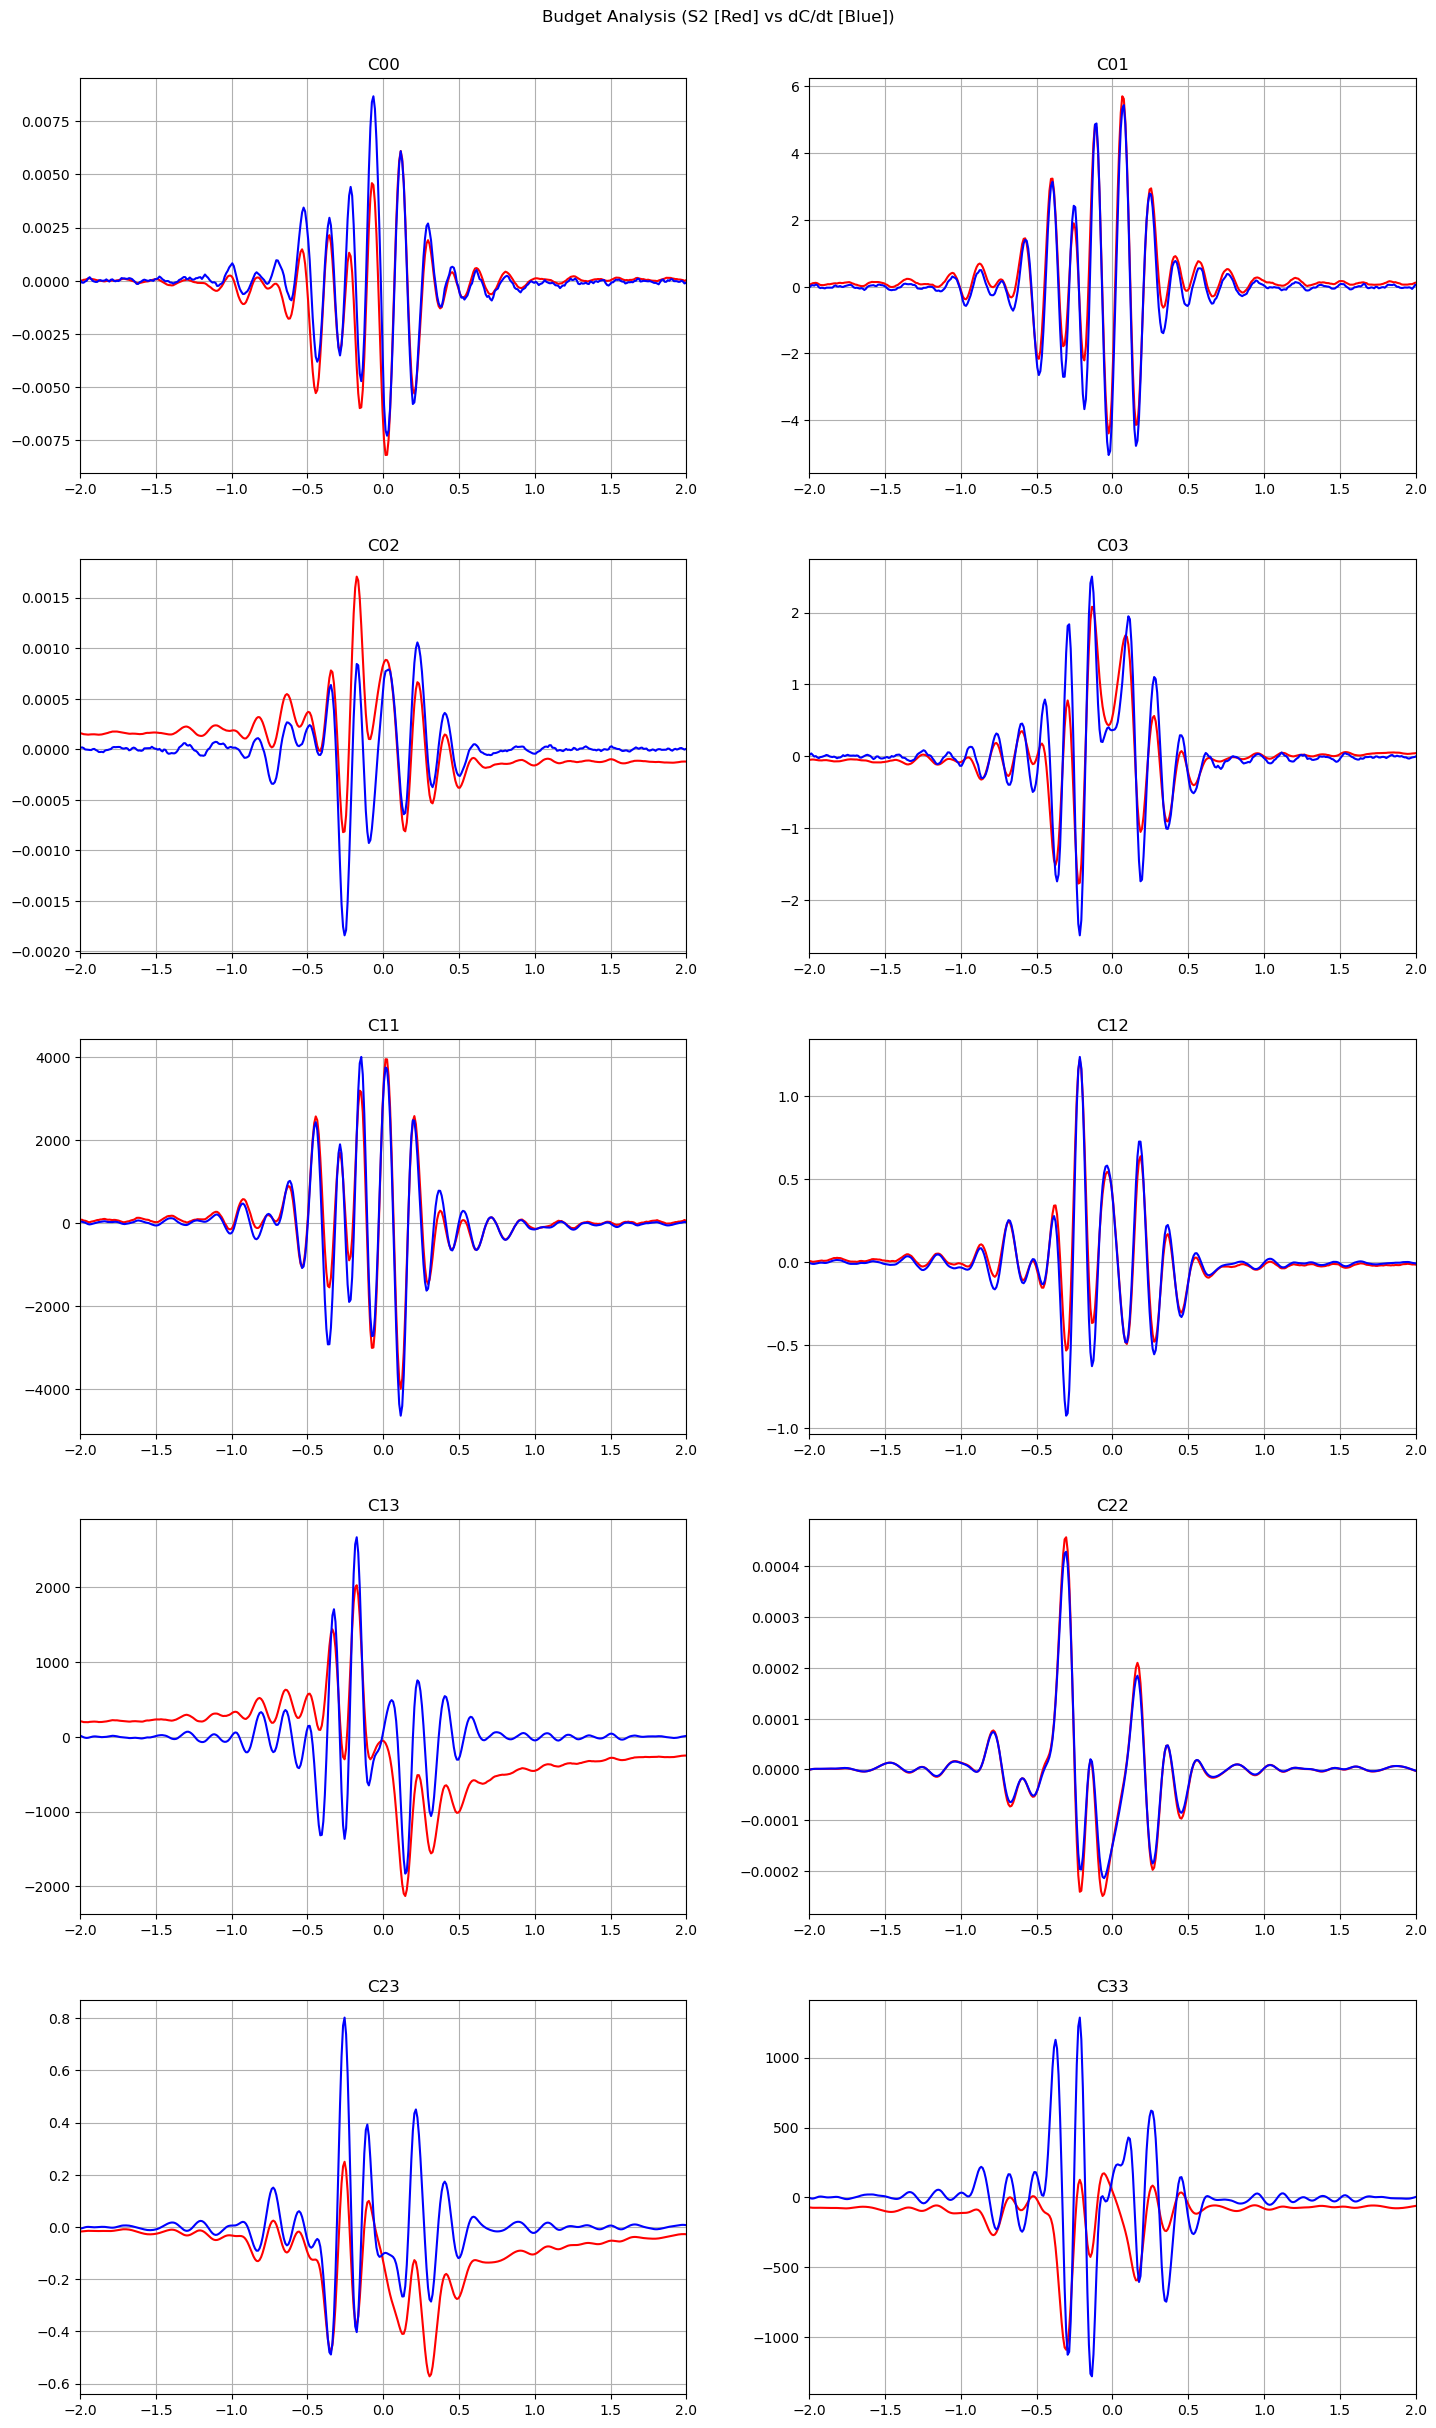

In [45]:
time_array = np.linspace(-5, 5, int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s2[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s2[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s2[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s2[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s2[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s2[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s2[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s2[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s2[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s2[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S2 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

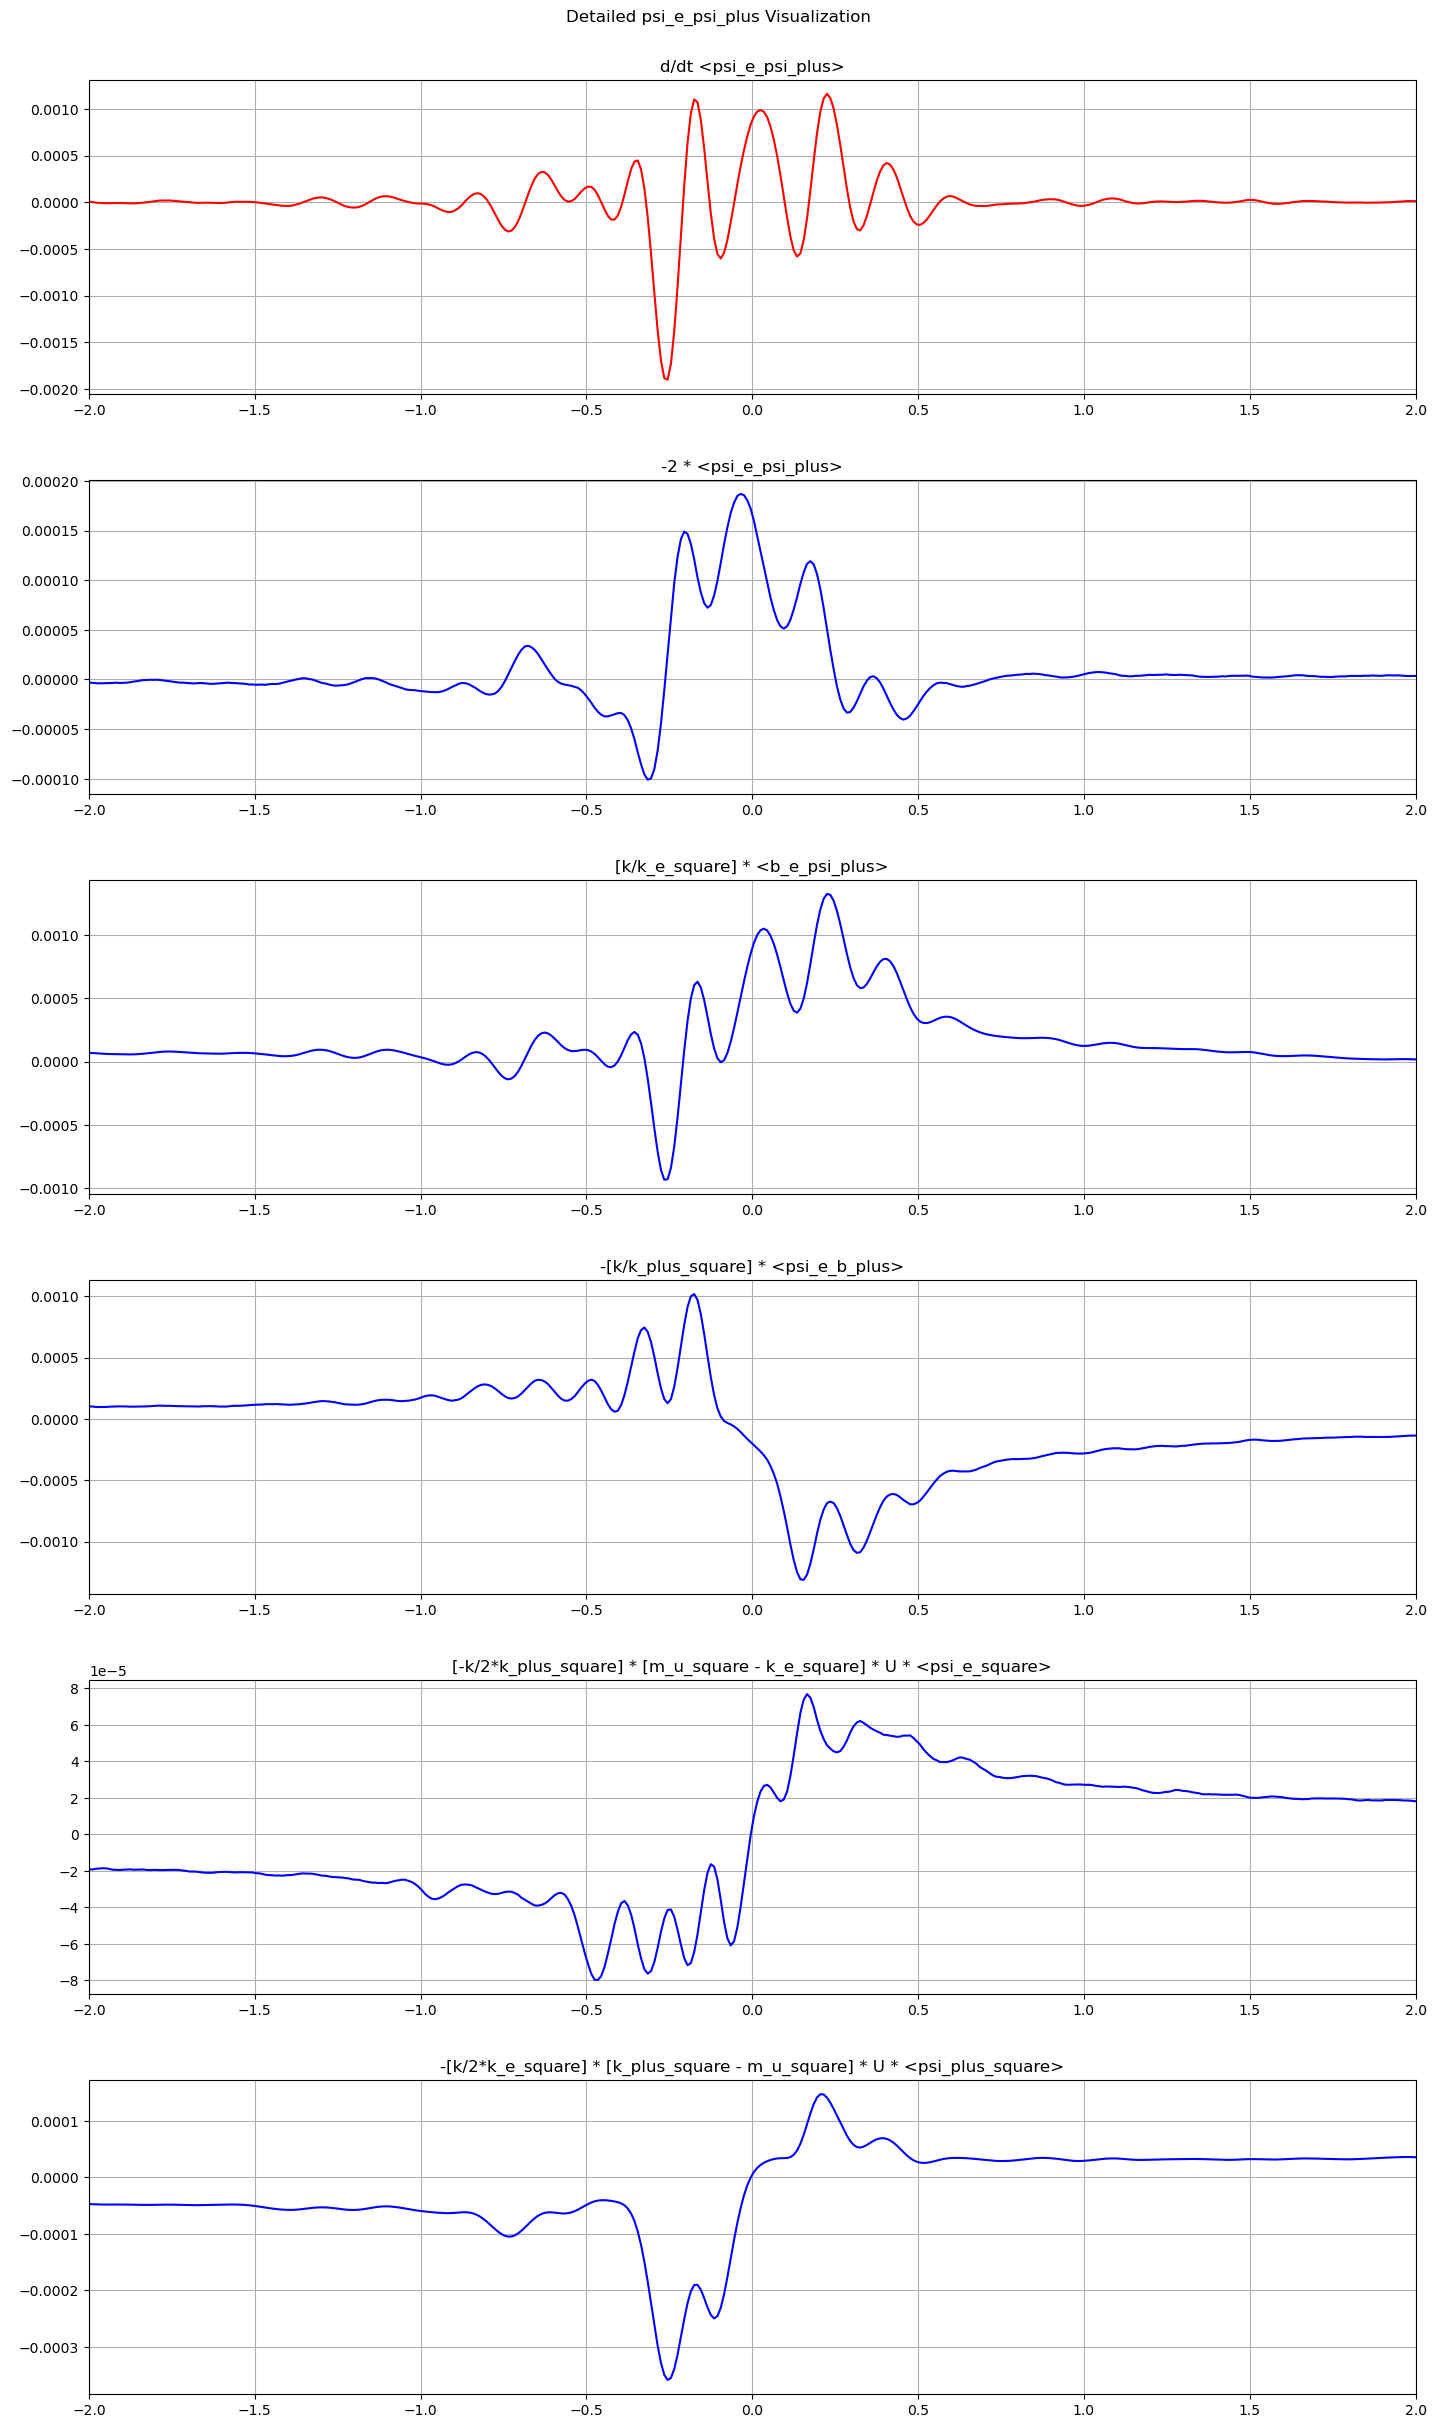

In [46]:
time_array = np.linspace(-5, 5, int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(6, 1, figsize=(15, 25))


axs[0].plot(time_array, s1[:, 0, 2],'r')
axs[0].set_title(f'd/dt <psi_e_psi_plus>')
axs[0].set_xlim(x_limit)
axs[0].grid()

axs[1].plot(time_array, -2 * average_R/(0.25 * k * (k_plus_square - k_e_square)),'b')
axs[1].set_title(f'-2 * <psi_e_psi_plus>')
axs[1].set_xlim(x_limit)
axs[1].grid()

axs[2].plot(time_array, (k/k_e_square) * average_b_e_psi_plus_list,'b')
axs[2].set_title(f'[k/k_e_square] * <b_e_psi_plus>')
axs[2].set_xlim(x_limit)
axs[2].grid()

axs[3].plot(time_array, (-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list,'b')
axs[3].set_title(f'-[k/k_plus_square] * <psi_e_b_plus>')
axs[3].set_xlim(x_limit)
axs[3].grid()

axs[4].plot(time_array, (-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e),'b')
axs[4].set_title(f'[-k/2*k_plus_square] * [m_u_square - k_e_square] * U * <psi_e_square>')
axs[4].set_xlim(x_limit) 
axs[4].grid()

axs[5].plot(time_array, (-k/(2*k_plus_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus),'b')
axs[5].set_title(f'-[k/2*k_e_square] * [k_plus_square - m_u_square] * U * <psi_plus_square>')
axs[5].set_xlim(x_limit)
axs[5].grid()


plt.suptitle(f"Detailed psi_e_psi_plus Visualization")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

In [47]:
# time_array = np.linspace(-5, 5, int(10/.01))
# # time_array = np.arange(2000/10, 2000/10) * dt * 10
# #fig, axs = plt.subplots(1,1, figsize = (8, 12))
# x_limit = (-2, 2)

# fig, axs = plt.subplots(1, 1, figsize=(12, 8))

# sumOfIndividualItems = (-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + ((-k/(2*k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# # sumOfIndividualItems = (-2 * average_R/(0.25 * k *fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# labels = [
#     'dC/dt[:, 0, 2]',
#     'sumOfIndividualItems',
#     '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
#     '(k/k_e_square) * average_b_e_psi_plus_list',
#     '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
#     '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
#     '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
# ]

# sumOfIndividualItems = ((k / k_e_square) * average_b_e_psi_plus_list) + \
#                        ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))
#                         # ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# # ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
# ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
# # ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # # ax.plot(time_array, average_R/1000, '-b', lw = 3)
# # ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
# # ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4])
# # ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
# # ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


# ax.set_xlim(x_limit)

# ax.grid(True)
# ax.set_xlabel("Time")
# ax.set_ylabel("Values")

# ax.legend(loc='best')

# plt.suptitle(f"Detailed psi_e_psi_plus Visualization", fontsize=16)

# plt.tight_layout(pad=3)
# plt.show() 

# (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list - ((k/k_e_square) * average_b_e_psi_plus_list[0])) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list - ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list[0])) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e) - ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e[0]))) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus[0])))

# # axs.plot(time_array, dC_dt[:, 0, 2],'r')
# axs.plot(time_array, dC_dt[:, 0, 2], 'b')
# axs.plot(time_array, sumOfIndividualItems,'g')
# # axs.plot(time_array, s1[:, 0, 2])
# # axs.plot(time_array, -2 * average_R/(0.25 * k * (k_plus_square - k_e_square)))
# # axs.plot(time_array, (k/k_e_square) * average_b_e_psi_plus_list)
# # axs.plot(time_array, (-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list)
# # axs.plot(time_array, -(k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e))
# # axs.plot(time_array, -(k/(2*k_plus_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus))
# axs.set_xlim(x_limit)
# axs.grid()


# plt.suptitle(f"Detailed psi_e_psi_plus Visualization (Same plot)")



# #plt.subplots_adjust(wspace=.4)
# #plt.subplots_adjust(hspace=.4)
# plt.tight_layout(pad = 3)
# plt.show()

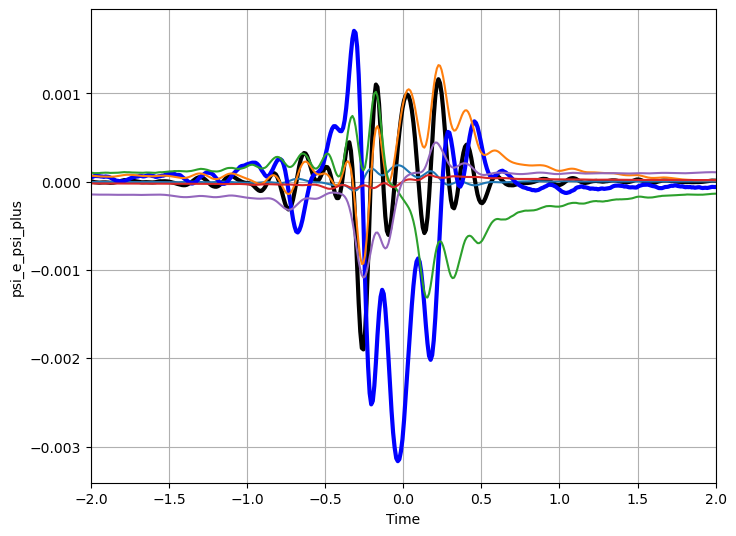

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

labels = [
    'dC/dt[:, 0, 2]',
    'psi_e_psi_plus',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]

sumOfIndividualItems = (-2 * average_R / (0.25 * k * (k_plus_square - k_e_square))) + \
                       ((k / k_e_square) * average_b_e_psi_plus_list) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list) + \
                       ((-k / (2 * k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + \
                       ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 3)
ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
ax.plot(time_array, average_R/1000, '-b', lw = 3)
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4])
ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("psi_e_psi_plus")

# ax.legend(loc='best')

# plt.suptitle(f"Detailed psi_e_psi_plus Visualization", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

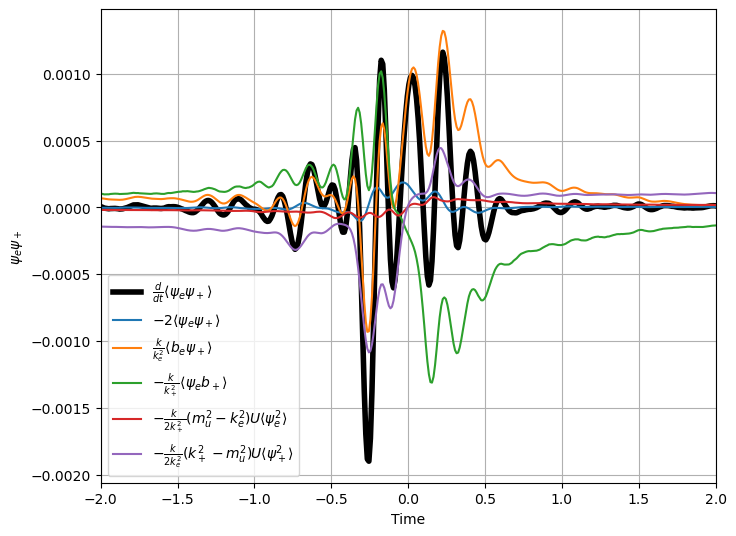

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot all terms with LaTeX-formatted labels
ax.plot(time_array, sumOfIndividualItems, '-k', lw=4, label=r"$\frac{d}{dt} \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)),
        label=r"$-2 \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list,
        label=r"$\frac{k}{k_e^2} \langle b_e \psi_+ \rangle$")
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list,
        label=r"$-\frac{k}{k_+^2} \langle \psi_e b_+ \rangle$")
ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e),
        label=r"$-\frac{k}{2k_+^2} (m_u^2 - k_e^2) U \langle \psi_e^2 \rangle$")
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus),
        label=r"$-\frac{k}{2k_e^2} (k_+^2 - m_u^2) U \langle \psi_+^2 \rangle$")

ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel(r"$\psi_e \psi_+$")

# Clean legend formatting
ax.legend(loc='best', fontsize=10)

plt.tight_layout(pad=3)
plt.show()


The green curve and the orange curve are responsible for the accleration of the jet near T = -0.4. These are also both heat fluxes. The terms driving the accleration is different from the ones causing the flip. 

### Pairwise Sum

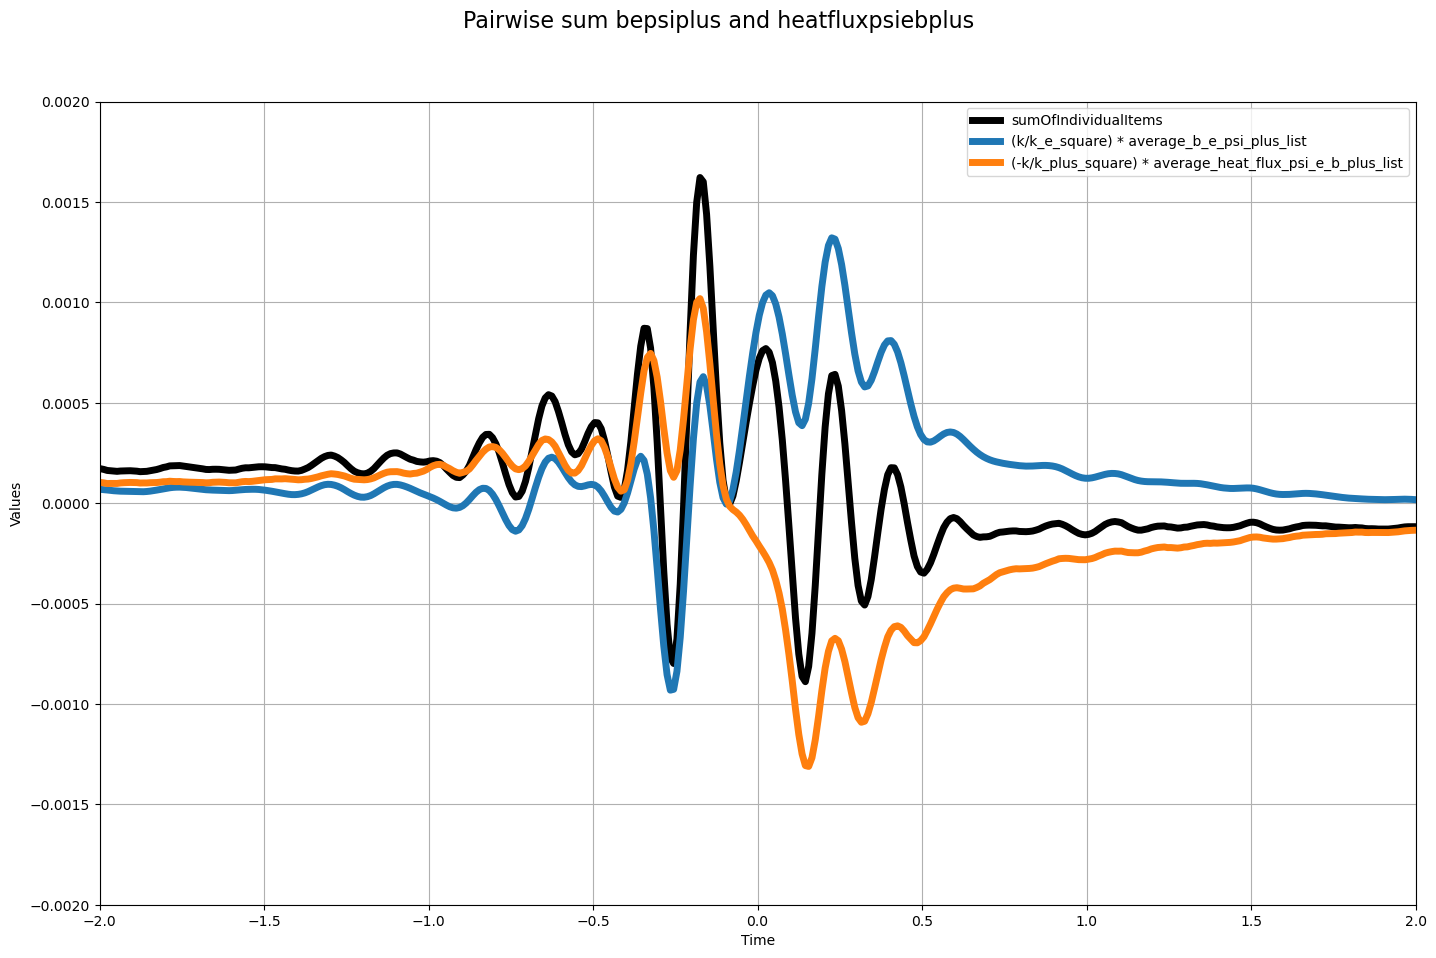

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]

sumOfIndividualItems = ((k / k_e_square) * average_b_e_psi_plus_list) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list) 
                        # ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
# ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # ax.plot(time_array, average_R/1000, '-b', lw = 3)
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3], lw = 5)
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4], lw = 5)
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
# ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.set_ylim((-.002, .002))
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")

ax.legend(loc='best')

plt.suptitle(f"Pairwise sum bepsiplus and heatfluxpsiebplus", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

#Sum of the 2 heat flux termslambda_values_filled = np.nan_to_num(lambda_values_truncat

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',labels[2],
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]lambda_values_filled = np.nan_to_num(lambda_values_truncat * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
ax.plot(time_array, ((k / k_e_square) * average_b_e_psi_plus_list),label=labels[3], lw = 5)
ax.plot(time_array, (-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus),label=labels[6], lw = 5)
# ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # ax.plot(time_array, average_R/1000, '-b', lw = 3)
# ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
# ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4])
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
# ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.set_ylim((-.002, .002))
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")
labels[2]
plt.show()

#Sum of the b_e_psi_plus + kinetic energy of exicted wave

SyntaxError: unmatched ')' (1711177651.py, line 11)

Reynold's Stress

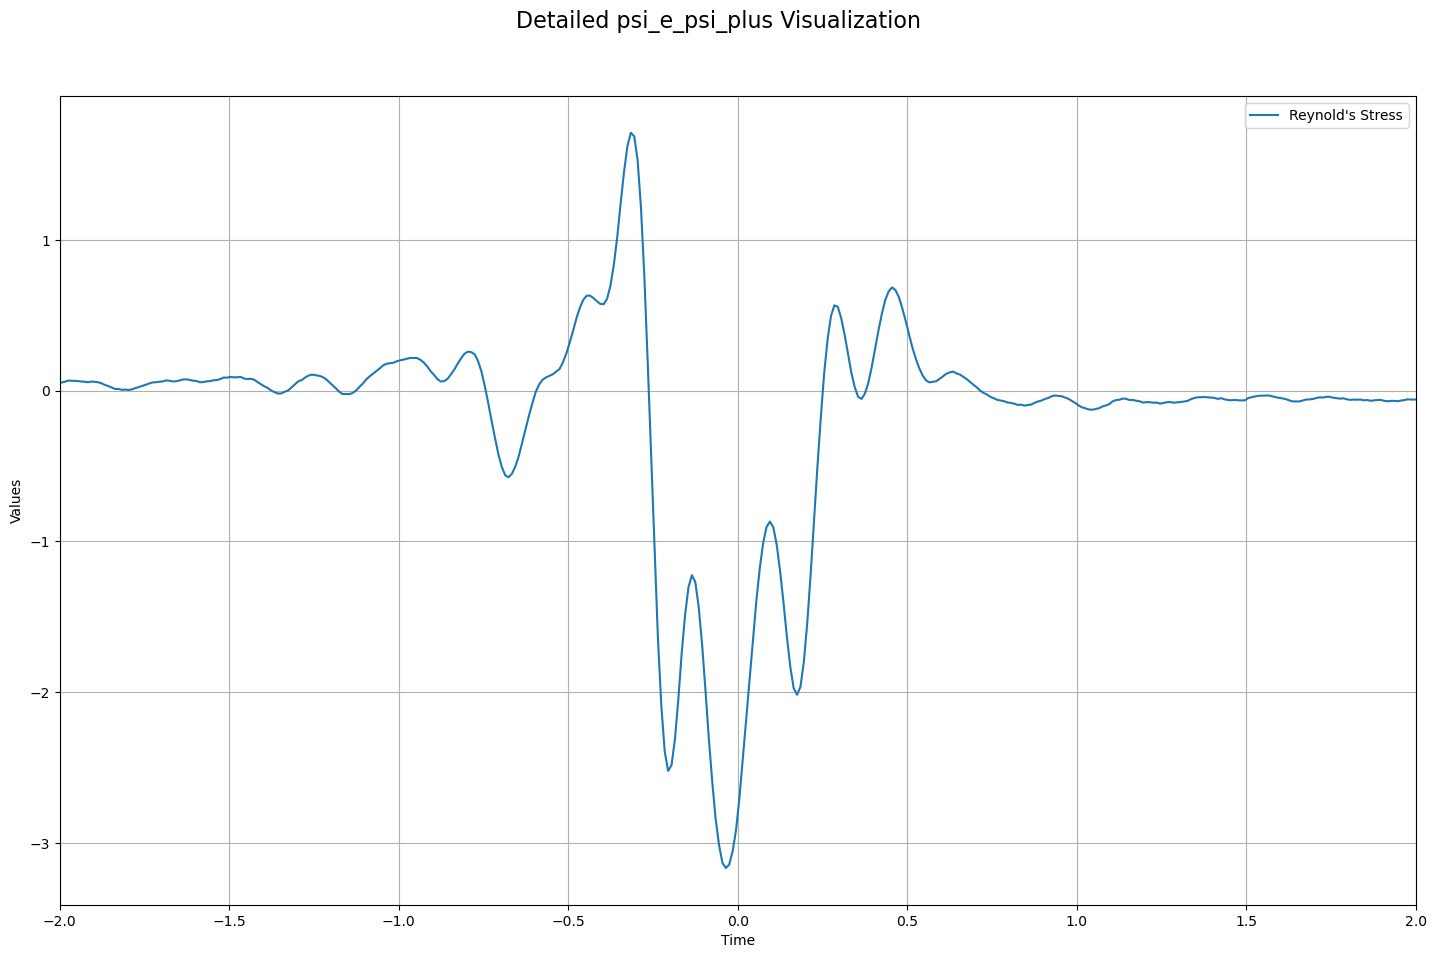

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]
labels[2]
sumOfIndividualItems = (-2 * average_R / (0.25 * k * (k_plus_square - k_e_square))) + \
                       ((k / k_e_square) * average_b_e_psi_plus_list) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list) + \
                       ((-k / (2 * k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + \
                       ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
# ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
ax.plot(time_array, average_R , label="Reynold's Stress")
# ax.plot(time_array, average_R/1000, '-b', lw = 3)
# ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
# ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4])
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
# ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")

ax.legend(loc='best')

plt.suptitle(f"Detailed psi_e_psi_plus Visualization", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))lambda_values_filled = np.nan_to_num(lambda_values_truncat

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'lambda_values_filled = np.nan_to_num(lambda_values_truncat
]

sumOfIndividualItems = -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list)
                        # ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
# ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # ax.plot(time_array, average_R/1000, '-b', lw = 3)
# ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4], lw = 5)
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6], lw = 5)


ax.set_xlim(x_limit)
ax.set_ylim((-.002, .002))
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")

ax.legend(loc='best')

plt.suptitle(f"Detailed psi_e_psi_plus Visualization", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

#Sum of kepsi plus and psiebpluslambda_values_filled = np.nan_to_num(lambda_values_truncat

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' on line 10 (1411912571.py, line 11)

In [54]:
C02 = average_C_matrix[:, 0, 2]
time_array = np.linspace(-5, 5, 1000)

spline = CubicSpline(time_array, C02)
# spline_derivative = spline.derivative()
# dc02 = spline_derivative(time_array)

time_fine = np.linspace(-5, 5, 10000)
C02_fine = spline(time_fine)
C02_derivative_fine = spline.derivative()(time_fine)
C02_derivative_fine = C02_derivative_fine[9::10]

In [55]:
lambda_values_filled = np.nan_to_num(lambda_values_truncatx_limit = (-2, 2)

fig, axs = plt.subplots(1, 1, figsize=(12, 8))

sumOfIndividualItems = (-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + ((-k/(2*k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# sumOfIndividualItems = (-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list - ((k/k_e_square) * average_b_e_psi_plus_list[0])) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list - ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list[0])) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e) - ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e[0]))) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus[0])))

# axs.plot(time_array, dC_dt[:, 0, 2],'r')
axs.plot(time_array, C02_derivative_fine, 'b')
axs.plot(time_array, sumOfIndividualItems,'g')
# axs.plot(time_array, s1[:, 0, 2])
# axs.plot(time_array, -2 * average_R/(0.25 * k * (k_plus_square - k_e_square)))
# axs.plot(time_array, (k/k_e_square) * average_b_e_psi_plus_list)
# axs.plot(time_array, (-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list)
# axs.plot(time_array, -(k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e))
# axs.plot(time_array, -(k/(2*k_plus_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus))
axs.set_xlim(x_limit)
axs.grid()


plt.suptitle(f"Detailed psi_e_psi_plus Visualization (Same plot)")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

SyntaxError: '(' was never closed (4100529952.py, line 1)

In [ ]:
x_limit = (-2, 2)

fig, axs = plt.subplots(1, 1, figsize=(12, 8))

axs.plot(time_array,  C02_derivative_fine - sumOfIndividualItems, 'r')
axs.set_xlim(x_limit)
axs.grid()


plt.suptitle(f"Detailed psi_e_psi_plus Visualization (Same plot)")
plt.tight_layout(pad = 3)
plt.show()


In [ ]:
s1 = average_WC + average_WC_Transpose + average_ULC + average_UCLT + epsilon*bigQ
# s1 *= 100

In [ ]:
average_C_matrix = np.array(average_C_Matrix)

delta_t = .001  

dC_dt = np.zeros_like(average_C_matrix)

dC_dt[0] = (average_C_matrix[1] - average_C_matrix[0]) / delta_tlambda_values_filled = np.nan_to_num(lambda_values_truncat

for i in range(1, len(average_C_matrix) - 1):
    dC_dt[i] = (average_C_matrix[i + 1] - average_C_matrix[i - 1]) / (2 * delta_t)

dC_dt[-1] = (average_C_matrix[-1] - average_C_matrix[-2]) / delta_t
dC_dt = dC_dt/10

In [ ]:
time_array = np.linspace(-5, 5, 1000)
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s1[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s1[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s1[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s1[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s1[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s1[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s1[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s1[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s1[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s1[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S1 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

In [ ]:
x_limit = (-2, 2)

fig, axs = plt.subplots(1, 1, figsize=(12, 8))

sumOfIndividualItems = (-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + ((-k/(2*k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# sumOfIndividualItems = (-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))) + ((k/k_e_square) * average_b_e_psi_plus_list - ((k/k_e_square) * average_b_e_psi_plus_list[0])) + ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list - ((-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list[0])) + ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e) - ((-k/(2*k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e[0]))) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus) - ((-k/(2*k_plus_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus[0])))

# axs.plot(time_array, dC_dt[:, 0, 2],'r')
axs.plot(time_array, dC_dt[:, 0, 2], 'b')
axs.plot(time_array, sumOfIndividualItems,'g')
# axs.plot(time_array, s1[:, 0, 2])lambda_values_filled = np.nan_to_num(lambda_values_truncat

plt.suptitle(f"Detailed psi_e_psi_plus Visualization (Same plot)")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

In [ ]:
C00 = average_C_matrix[:, 0, 0]
time_array = np.linspace(-5, 5, 1000)

spline = CubicSpline(time_array, C00)
# spline_derivative = spline.derivative()
# dc02 = spline_derivative(time_array)

time_fine = np.linspace(-5, 5, 10000)
C00_fine = spline(time_fine)
C00_derivative_fine = spline.derivative()(time_fine)
C00_derivative_fine = C00_derivative_fine[9::10]

In [ ]:
plt.plot(time_array, average_U * average_k_e_psi_e_list)

In [56]:
U_k_e_psi_e = np.array([
    np.array(u) * np.array(k)
    for u, k in zip(df['u_list'], df['k_e_psi_e_list'])
])


In [57]:
U_k_e_psi_e_average = average_arrays(*list(U_k_e_psi_e))

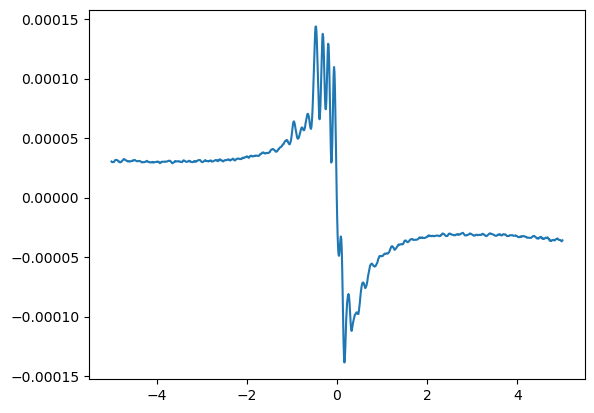

In [58]:
plt.plot(time_array, U_k_e_psi_e_average)

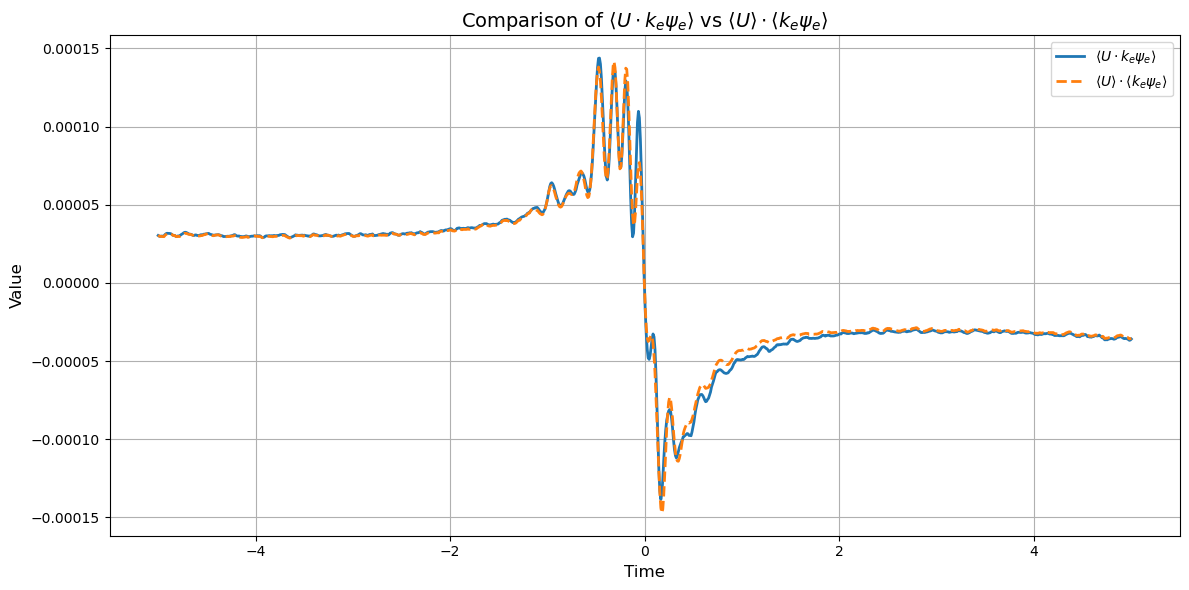

In [59]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_array, U_k_e_psi_e_average, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, average_U * average_k_e_psi_e_list, 
        label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', linestyle='--', linewidth=2)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(r'Comparison of $\langle U \cdot k_{e}\psi_{e} \rangle$ vs $\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()


In [60]:
standard_error_diff= np.std(U_k_e_psi_e_average-(average_U * average_k_e_psi_e_list), axis=0) / np.sqrt(1000)

In [61]:
standard_error_diff

1.2331295380155938e-07

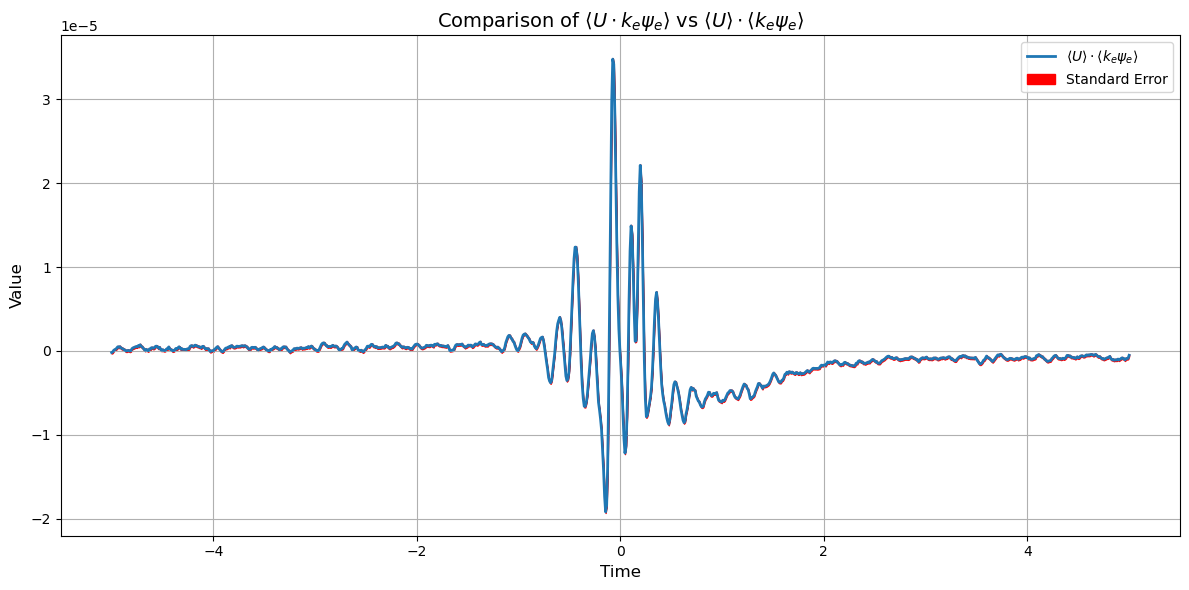

In [62]:
fig, ax = plt.subplots(figsize=(12, 6))
calc_array = U_k_e_psi_e_average-(average_U * average_k_e_psi_e_list)
# ax.plot(time_array, U_k_e_psi_e_average, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, calc_array,
        label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', linestyle='-', linewidth=2)

ax.fill_between(time_array, 
                calc_array - standard_error_diff, 
                calc_array + standard_error_diff, 
                alpha=1, label='Standard Error',color='red')

# ax.errorbar(time_array, 
#             U_k_e_psi_e_average - (average_U * average_k_e_psi_e_list), 
#             yerr=standard_error_diff, 
#             label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', 
#             linestyle='--', 
#             linewidth=2, 
#             capsize=3)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(r'Comparison of $\langle U \cdot k_{e}\psi_{e} \rangle$ vs $\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()



In [63]:
def std_across_axis(arrays):
    return np.std(arrays, axis=0)

In [64]:
U_k_e_psi_plus = np.array([
    np.array(u) * np.array(k)
    for u, k in zip(df['u_list'], df['k_e_psi_plus_list'])
])


In [65]:
U_k_e_psi_plus_stdev = std_across_axis(U_k_e_psi_plus)

In [66]:
U_k_e_psi_plus_stdev.shape

(1000,)

In [67]:
U_k_e_psi_plus_stError = U_k_e_psi_plus_stdev/100

In [68]:
U_k_e_psi_plus.shape

(5000, 1000)

In [69]:
U_k_e_psi_plus_average = average_arrays(*list(U_k_e_psi_plus))

In [70]:
U_k_e_psi_plus_average.shape

(1000,)

In [71]:
average_U_Ke_psi_plus = average_U * average_k_e_psi_plus_list
average_U_Ke_psi_plus.shape

(1000,)

In [72]:
std_U = np.std(df['u_list'].tolist(), axis=0)
std_K_e_psi_plus = np.std(df['k_e_psi_plus_list'].tolist(), axis=0)
std_U.shape, std_K_e_psi_plus.shape

((1000,), (1000,))

In [73]:
std_err_U = std_U / 100
std_err_k_e_psi_plus = std_K_e_psi_plus / 100

In [74]:
st_err_U_K_e_psi_plus = average_U * average_k_e_psi_plus_list * np.sqrt((std_err_U / average_U) ** 2 + (std_err_k_e_psi_plus / average_k_e_psi_plus_list) ** 2)
st_err_U_K_e_psi_plus.shape

(1000,)

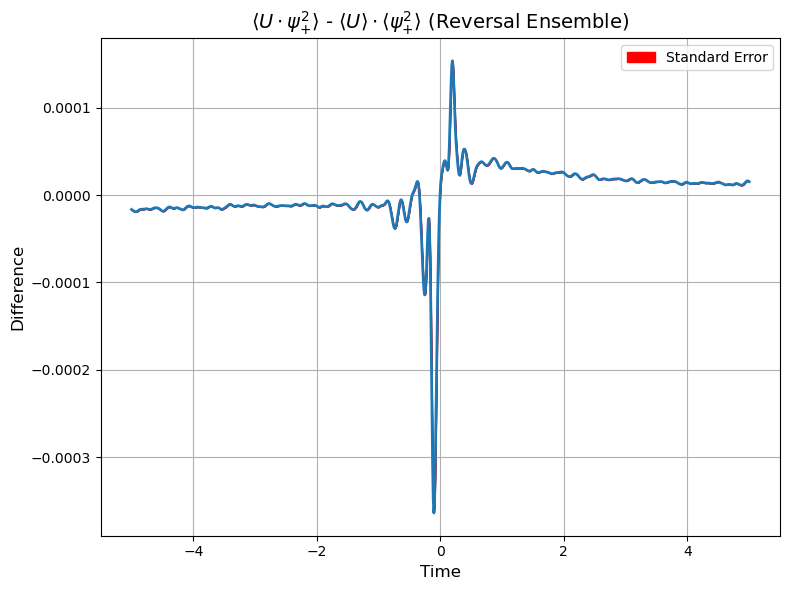

In [85]:
fig, ax = plt.subplots(figsize=(8, 6))
standard_error_diff = np.sqrt(st_err_U_K_e_psi_plus ** 2 + U_k_e_psi_plus_stError ** 2)
calc_array = U_k_e_psi_plus_average - average_U_Ke_psi_plus
calc_array = -(k/(2*k_e_square))*(k_plus_square-(m_u**2))*calc_array
# ax.plot(time_array, U_k_e_psi_plus_average, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, calc_array,linestyle='-', linewidth=2)

ax.fill_between(time_array, 
                calc_array - standard_error_diff, 
                calc_array + standard_error_diff, 
                alpha=1, label='Standard Error',color='red')

# ax.errorbar(time_array, 
#             U_k_e_psi_e_average - (a
#             capsize=3)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Difference', fontsize=12)
ax.set_title(r'$\langle U \cdot \psi_{+}^2 \rangle$ - $\langle U \rangle \cdot \langle \psi_{+}^2 \rangle$ (Reversal Ensemble)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)
# ax.set_ylim(-4e-5, 4e-5)

plt.tight_layout()
plt.show()


NameError: name 'st_err_U_K_e_psi_e' is not defined

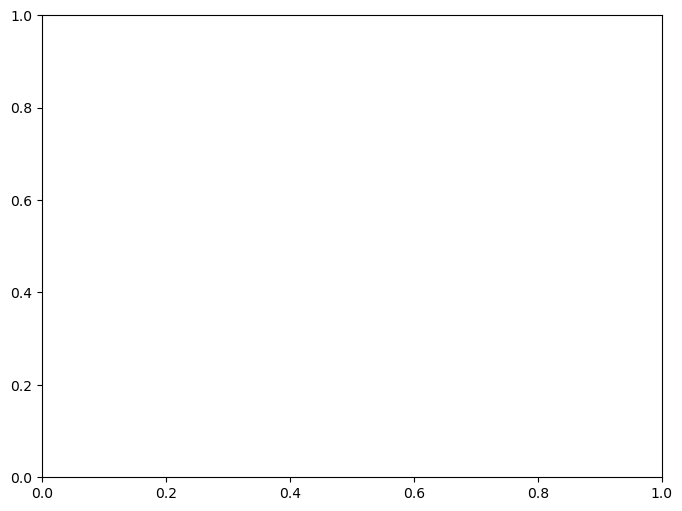

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# assuming these exist:
# time_array
# st_err_U_K_e_psi_e
# U_k_e_psi_e_stError
# U_k_e_psi_e_average
# average_U_Ke_psi_e

fig, ax = plt.subplots(figsize=(8, 6))

standard_error_diff = np.sqrt(st_err_U_K_e_psi_e ** 2 + U_k_e_psi_e_stError ** 2)
calc_array = U_k_e_psi_e_average - average_U_Ke_psi_e

# ===================== MAIN PLOT =====================
ax.plot(time_array, calc_array, linestyle='-', linewidth=2, label='Difference')

ax.fill_between(
    time_array,
    calc_array - standard_error_diff,
    calc_array + standard_error_diff,
    alpha=1,
    label='Standard Error',
    color='red'
)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Difference', fontsize=12)
ax.set_title(
    r'$\langle U \cdot \psi_{e}^2 \rangle$ - $\langle U \rangle \cdot \langle \psi_{e}^2 \rangle$ (Reversal Ensemble)',
    fontsize=14
)
ax.legend(fontsize=10)
ax.set_ylim(-4e-5, 4e-5)
ax.grid(True)

# ===================== INSET SETUP =====================
# center & window in time you want to zoom around
t_center = -3.5
t_half = 1.5           # window: [t_center - t_half, t_center + t_half]
t1, t2 = t_center - t_half, t_center + t_half

mask = (time_array >= t1) & (time_array <= t2)

# vertical limits based on data ± error in that window
local_lower = (calc_array - standard_error_diff)[mask]
local_upper = (calc_array + standard_error_diff)[mask]
y_min = np.min(local_lower)
y_max = np.max(local_upper)
pad = 0.1 * (y_max - y_min) if y_max > y_min else 1e-6
# pad = 0.1 * (y_max - y_min) 

# ===================== INSET AXES (BOTTOM-RIGHT, SQUARE) =====================
# We use bbox_to_anchor in *axes* coordinates to control position:
# (x0, y0, width, height), all in [0, 1] relative to the main axes.
ax_ins = inset_axes(
    ax,
    width="115%",                # size relative to bbox_to_anchor
    height="60%",
    loc="lower left",           # corner of the inset that attaches to bbox
    bbox_to_anchor=(0.10, .6, 0.25, 0.30),  # bottom-right-ish, square-ish
    bbox_transform=ax.transAxes,
    borderpad=0
)

# same line + shading inside inset
ax_ins.plot(time_array, calc_array, linestyle='-', linewidth=1.0)
ax_ins.fill_between(
    time_array,
    calc_array - standard_error_diff,
    calc_array + standard_error_diff,
    alpha=1,
    color='red'
)

ax_ins.set_xlim(t1, t2)
ax_ins.set_ylim(-2e-6, 2e-6)

# clean inset ticks (comment out if you want them)
# ax_ins.set_xticks([])
# ax_ins.set_yticks([])

# rectangle + one connector between main and inset
pp, p1, p2 = mark_inset(ax, ax_ins, loc1=4, loc2=1, fc="none", ec="0.5")
pp.set_edgecolor("black")
pp.set_linewidth(2.0)


p2.set_visible(False)
p1.set_linewidth(2.0)
p1.set_color("black")
p1.set_alpha(0.9)

plt.tight_layout()
plt.show()


3Corr For psi e psi plus Interesting, so this does include the 3corr

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot all terms with LaTeX-formatted labels
ax.plot(time_array, sumOfIndividualItems, '-k', lw=4, label=r"$\frac{d}{dt} \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)),
        label=r"$-2 \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list,
        label=r"$\frac{k}{k_e^2} \langle b_e \psi_+ \rangle$")
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list,
        label=r"$-\frac{k}{k_+^2} \langle \psi_e b_+ \rangle$")
ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e),
        label=r"$-\frac{k}{2k_+^2} (m_u^2 - k_e^2) U \langle \psi_e^2 \rangle$")
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus),
        label=r"$-\frac{k}{2k_e^2} (k_+^2 - m_u^2) U \langle \psi_+^2 \rangle$")

ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel(r"$\psi_e \psi_+$")

# Clean legend formatting
ax.legend(loc='best', fontsize=10)

plt.tight_layout(pad=3)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot all terms with LaTeX-formatted labels
ax.plot(time_array, sumOfIndividualItems, '-k', lw=4, label=r"$\frac{d}{dt} \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)),
        label=r"$-2 \langle \psi_e \psi_+ \rangle$")
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list,
        label=r"$\frac{k}{k_e^2} \langle b_e \psi_+ \rangle$")
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list,
        label=r"$-\frac{k}{k_+^2} \langle \psi_e b_+ \rangle$")
ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_U * average_k_e_psi_e_list),
        label=r"$-\frac{k}{2k_+^2} (m_u^2 - k_e^2)  \langle U \psi_e^2 \rangle$")
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_U * average_k_e_psi_plus_list),
        label=r"$-\frac{k}{2k_e^2} (k_+^2 - m_u^2)  \langle U \psi_+^2 \rangle$")

ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel(r"$\psi_e \psi_+$")

# Clean legend formatting
ax.legend(loc='best', fontsize=10)

plt.tight_layout(pad=3)
plt.show()